[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter6_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 6: Multivariate Volatility and Dependence

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Computes the charts and results of Chapter 6 on real daily data.
- Stocks and bonds (SPY, TLT), US, euro-area and Romanian equities, Bitcoin and six banks.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx
from scipy import stats, optimize, integrate
from scipy.signal import lfilter
from scipy.special import gammaln
try:
    from arch import arch_model
except ImportError:                      # Colab: pip install arch
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=True)
    from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
FAM_COL = {'gaussian': MainBlue, 't': IDAred, 'clayton': Forest, 'gumbel': Amber, 'frank': Purple}

SIDE = (5.6, 3.5)   # size of the charts placed next to text

SEED = 42
NUM = {}
TABLE_DIR = '.'


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def shade_crises(ax, alpha=0.5):
    for a, b in (('2008-09-15', '2009-03-31'), ('2020-02-20', '2020-04-30'), ('2022-01-03', '2022-10-31')):
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=BandBlue, alpha=alpha, lw=0)


import tempfile
SAVE_OUT = globals().get('SAVE_TO_DRIVE', False)   # set in the Drive cell at the top
OUT_DIR = globals().get('OUT_DIR', '.')
TABLE_DIR = OUT_DIR if SAVE_OUT else tempfile.gettempdir()   # tables: Drive folder or a temporary folder


def save_fig(name):
    """Save the figure in OUT_DIR (PDF and PNG) when SAVE_TO_DRIVE is on, then show it."""
    if SAVE_OUT:
        plt.savefig(os.path.join(OUT_DIR, f'{name}.pdf'), bbox_inches='tight', transparent=True)
        plt.savefig(os.path.join(OUT_DIR, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()

## Data

- Daily prices up to 18 September 2026: SPY, TLT, S&P 500, Euro Stoxx 50, BET, Bitcoin and six banks.
- ETFs and stocks: adjusted closes; indices and Bitcoin: closes.
- Joint analyses: prices are aligned on common trading days first, then log returns are computed.
- Weekly returns use the last common close of each week (Friday).

In [3]:
import os
import numpy as np
import pandas as pd

REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, price field, label, start date)
ASSETS = {
    'spy':   ('SPY.US',        'adjusted_close', 'SPY (S&P 500 ETF)',          '2002-07-30'),
    'tlt':   ('TLT.US',        'adjusted_close', 'TLT (20+y Treasury ETF)',    '2002-07-30'),
    'ief':   ('IEF.US',        'adjusted_close', 'IEF (7-10y Treasury ETF)',   '2002-07-30'),
    'sp500': ('GSPC.INDX',     'close',          'S&P 500',                    '2000-01-01'),
    'stoxx': ('STOXX50E.INDX', 'close',          'Euro Stoxx 50',              '2000-01-01'),
    'bet':   ('BET',           'close',          'BET (Romania)',              '2000-01-01'),
    'bettr': ('BETTR.INDX',    'close',          'BET-TR (Romania)',           '2014-09-23'),
    'btc':   ('BTC-USD.CC',    'close',          'Bitcoin',                    '2014-09-17'),
    'vix':   ('VIX.INDX',      'close',          'VIX',                        '2000-01-01'),
    'jpm':   ('JPM.US',        'adjusted_close', 'JPMorgan Chase',             '2010-01-01'),
    'bac':   ('BAC.US',        'adjusted_close', 'Bank of America',            '2010-01-01'),
    'dbk':   ('DBK.XETRA',     'adjusted_close', 'Deutsche Bank',              '2010-01-01'),
    'bnp':   ('BNP.PA',        'adjusted_close', 'BNP Paribas',                '2010-01-01'),
    'tlv':   ('TLV.RO',        'adjusted_close', 'Banca Transilvania',         '2010-01-01'),
    'brd':   ('BRD.RO',        'adjusted_close', 'BRD-Groupe Societe Generale', '2010-01-01'),
}
# US-listed ETFs for the COVOL case study (Engle and Campos-Martins, 2023, Section 9)
COVOL_ETFS = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY',
              'IWF', 'IWD', 'IWM', 'EFA', 'EEM', 'GLD', 'TLT', 'LQD', 'USO']
for _e in COVOL_ETFS:
    ASSETS['etf_' + _e.lower()] = (f'{_e}.US', 'adjusted_close', _e, '1999-12-31')
LABELS = {k: v[2] for k, v in ASSETS.items()}
SHORT = {'spy': 'SPY', 'tlt': 'TLT', 'ief': 'IEF', 'sp500': 'S&P 500', 'stoxx': 'Euro Stoxx 50', 'bet': 'BET',
         'bettr': 'BET-TR', 'btc': 'Bitcoin', 'vix': 'VIX', 'jpm': 'JPM', 'bac': 'BAC', 'dbk': 'DBK', 'bnp': 'BNP',
         'tlv': 'TLV', 'brd': 'BRD'}
BANKS = ['jpm', 'bac', 'dbk', 'bnp', 'tlv', 'brd']


def read_market(symbol):
    """Daily series of one asset from the course data."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def load_price(name, start=None, end=END):
    """Daily price, cleaned with the conventions of the chapter."""
    symbol, col, _, start0 = ASSETS[name]
    d = read_market(symbol).loc[start or start0:end]
    d = d[d[col] > 0].dropna(subset=[col])
    s = d[col]
    if name != 'btc':
        keep = s.index.dayofweek < 5                                   # no weekend quotes
        vol = d['volume'].fillna(0) if 'volume' in d else pd.Series(0.0, index=d.index)
        keep &= ~((s.diff() == 0) & (vol <= 0)).values                # holidays: unchanged price AND zero volume
        s = s[keep]                                                    # (trading days with volume and an unchanged price stay)
    return s.rename(name)


def joint_prices(names, start=None, end=END):
    """Prices of the assets on their common trading days."""
    return pd.concat([load_price(n, start, end) for n in names], axis=1, join='inner').dropna()


def joint_returns(names, start=None, end=END):
    """Daily log returns, computed AFTER aligning the prices on common days."""
    return np.log(joint_prices(names, start, end)).diff().dropna()


def weekly_returns(names, start=None, end=END):
    """Weekly log returns: the last common price of each week (Friday), then differences."""
    p = joint_prices(names, start, end)
    return np.log(p.resample('W-FRI').last()).diff().dropna()

## Dependence tools

- EWMA and rolling covariances, Fisher intervals.
- Univariate GARCH(1,1) and the two-step DCC(1,1) of Engle (2002).
- Forbes–Rigobon adjustment, exceedance correlations.
- Five bivariate copulas: density, conditional distribution $h(v\mid u)$, simulation, $\tau$ mapping, tail dependence, canonical maximum likelihood and the Rosenblatt goodness-of-fit test with parametric bootstrap.

In [4]:
import numpy as np
import pandas as pd
from scipy import stats, optimize, integrate
from scipy.signal import lfilter
from scipy.special import gammaln
from arch import arch_model
try:
    from numba import njit
except ImportError:                      # without numba the same functions run as plain Python (slower)
    def njit(*args, **kwargs):
        return args[0] if (len(args) == 1 and callable(args[0])) else (lambda f: f)


# =============================================================================
# EWMA and rolling window
# =============================================================================
def ewma_cov(R, lam=0.94, init=100):
    """Sigma_t = lam*Sigma_{t-1} + (1-lam) r_{t-1} r_{t-1}'  (forecast for day t, without r_t).
    The first init observations only initialise the recursion: Sigma_init = their covariance; NaN before init."""
    X = np.asarray(R, dtype=float)
    T, N = X.shape
    S = np.full((T, N, N), np.nan)
    S[init] = np.cov(X[:init].T)
    for t in range(init + 1, T):
        S[t] = lam * S[t - 1] + (1 - lam) * np.outer(X[t - 1], X[t - 1])
    return S


def ewma_corr(R, lam=0.94, i=0, j=1):
    S = ewma_cov(R, lam)
    return pd.Series(S[:, i, j] / np.sqrt(S[:, i, i] * S[:, j, j]), index=R.index)


def rolling_corr(R, window, a=None, b=None):
    a, b = a or R.columns[0], b or R.columns[1]
    return R[a].rolling(window).corr(R[b])


def fisher_ci(rho, n, level=0.95):
    """Confidence interval for a correlation by the Fisher z transformation (i.i.d. data)."""
    z, se = np.arctanh(rho), 1 / np.sqrt(n - 3)
    q = stats.norm.ppf(0.5 + level / 2)
    return np.tanh(z - q * se), np.tanh(z + q * se)


# =============================================================================
# Univariate GARCH(1,1) -- the first step of DCC
# =============================================================================
def garch_filter(r, dist='normal'):
    """GARCH(1,1) with constant mean on returns in percent (QML).
    Returns the parameters, the conditional volatility (%) and the standardised residuals."""
    res = arch_model(100 * r, mean='Constant', vol='GARCH', p=1, q=1, dist=dist).fit(disp='off')
    z = (res.resid / res.conditional_volatility).rename(r.name)
    return res.params, res.conditional_volatility.rename(r.name), z, res.loglikelihood


def garch_all(R, dist='normal'):
    out = {c: garch_filter(R[c], dist) for c in R.columns}
    Z = pd.concat([out[c][2] for c in R.columns], axis=1)
    V = pd.concat([out[c][1] for c in R.columns], axis=1)
    P = pd.DataFrame({c: out[c][0] for c in R.columns})
    ll = sum(out[c][3] for c in R.columns)
    return P, V, Z, ll


# =============================================================================
# DCC (Engle, 2002): Q_t = (1-a-b) Qbar + a z_{t-1} z_{t-1}' + b Q_{t-1}
# =============================================================================
def dcc_path(Z, a, b, Qbar=None):
    """Correlation matrices R_t (T x N x N). Each element of Q_t follows a linear recursion,
    computed in vectorised form with lfilter."""
    X = np.asarray(Z, dtype=float)
    T, N = X.shape
    Qbar = np.cov(X.T, bias=True) if Qbar is None else Qbar
    P = np.einsum('ti,tj->tij', X, X)                  # z_t z_t'
    drive = np.empty_like(P)
    drive[0] = Qbar
    drive[1:] = (1 - a - b) * Qbar + a * P[:-1]         # input at time t: uses z_{t-1}
    Q = lfilter([1.0], [1.0, -b], drive.reshape(T, -1), axis=0).reshape(T, N, N)
    Q[0] = Qbar
    d = np.sqrt(np.einsum('tii->ti', Q))
    return Q / (d[:, :, None] * d[:, None, :])


@njit(cache=True)
def dcc2_corr_loglik(x, y, a, b, q11b, q22b, q12b):
    """Bivariate case of dcc_corr_loglik, written as a single loop (same recursion as dcc_path)."""
    q11, q22, q12 = q11b, q22b, q12b
    c = 1.0 - a - b
    ll = 0.0
    for t in range(len(x)):
        r = q12 / np.sqrt(q11 * q22)
        d = 1.0 - r * r
        ll += -0.5 * (np.log(d) + (x[t] * x[t] + y[t] * y[t] - 2.0 * r * x[t] * y[t]) / d - x[t] * x[t] - y[t] * y[t])
        q11 = c * q11b + a * x[t] * x[t] + b * q11
        q22 = c * q22b + a * y[t] * y[t] + b * q22
        q12 = c * q12b + a * x[t] * y[t] + b * q12
    return ll


def dcc_corr_loglik(Z, a, b, Qbar=None):
    """Correlation part of the log-likelihood: -1/2 sum(log|R_t| + z'R_t^{-1}z - z'z)."""
    X = np.asarray(Z, dtype=float)
    if X.shape[1] == 2:
        Q = np.cov(X.T, bias=True) if Qbar is None else Qbar
        return dcc2_corr_loglik(np.ascontiguousarray(X[:, 0]), np.ascontiguousarray(X[:, 1]), float(a), float(b),
                                Q[0, 0], Q[1, 1], Q[0, 1])
    R = dcc_path(X, a, b, Qbar)
    sign, logdet = np.linalg.slogdet(R)
    quad = np.einsum('ti,tij,tj->t', X, np.linalg.inv(R), X)
    return -0.5 * np.sum(logdet + quad - np.sum(X ** 2, axis=1))


def ccc_loglik(Z):
    """CCC (Bollerslev, 1990): constant correlation = DCC with a = b = 0."""
    return dcc_corr_loglik(Z, 0.0, 0.0)


def _num_hessian(f, x, h=1e-4):
    k = len(x)
    H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            e_i, e_j = np.eye(k)[i] * h, np.eye(k)[j] * h
            H[i, j] = (f(x + e_i + e_j) - f(x + e_i - e_j) - f(x - e_i + e_j) + f(x - e_i - e_j)) / (4 * h * h)
    return H


def dcc_fit(Z, start=(0.03, 0.95)):
    """Step 2 of DCC: (a, b) by maximum likelihood, with Qbar fixed at the sample correlation
    (correlation targeting). The standard errors come from the step-2 Hessian (they ignore the step-1 error)."""
    X = np.asarray(Z, dtype=float)
    Qbar = np.cov(X.T, bias=True)

    def nll(p):
        a, b = p
        if a < 0 or b < 0 or a + b >= 0.9999:
            return 1e10
        return -dcc_corr_loglik(X, a, b, Qbar)

    best = None
    for s in (start, (0.01, 0.98), (0.05, 0.90), (0.10, 0.80)):
        r = optimize.minimize(nll, s, method='Nelder-Mead', options=dict(xatol=1e-7, fatol=1e-7, maxiter=4000))
        if best is None or r.fun < best.fun:
            best = r
    a, b = best.x
    try:
        H = _num_hessian(lambda p: -nll(p), best.x)
        se = np.sqrt(np.diag(np.linalg.inv(-H)))
    except Exception:
        se = np.array([np.nan, np.nan])
    return dict(a=a, b=b, se_a=se[0], se_b=se[1], loglik=-best.fun, Qbar=Qbar,
                R=dcc_path(X, a, b, Qbar), ccc_loglik=ccc_loglik(X))


# =============================================================================
# Forbes-Rigobon (2002)
# =============================================================================
def fr_adjust(rho_c, delta):
    """Crisis correlation adjusted for the rise in the variance of the source market:
    rho* = rho_c / sqrt(1 + delta (1 - rho_c^2)), delta = Var_crisis/Var_calm - 1."""
    return rho_c / np.sqrt(1 + delta * (1 - rho_c ** 2))


def fr_inflation(rho, delta):
    """Correlation measured in the crisis when the true correlation does not change: rho sqrt((1+delta)/(1+delta rho^2))."""
    return rho * np.sqrt((1 + delta) / (1 + delta * rho ** 2))


def fisher_z_test(rho1, n1, rho0, n0):
    """H0: rho1 <= rho0 (one-sided test, independent samples)."""
    z = (np.arctanh(rho1) - np.arctanh(rho0)) / np.sqrt(1 / (n1 - 3) + 1 / (n0 - 3))
    return z, 1 - stats.norm.cdf(z)


def crisis_table(ret2, source, targets, calm, crisis):
    """Calm vs crisis correlation, the Forbes-Rigobon adjustment and the Fisher z test for several markets."""
    rows = []
    c0, c1 = ret2.loc[calm[0]:calm[1]], ret2.loc[crisis[0]:crisis[1]]
    delta = c1[source].var() / c0[source].var() - 1
    for tg in targets:
        r0, r1 = c0[source].corr(c0[tg]), c1[source].corr(c1[tg])
        adj = fr_adjust(r1, delta)
        n0, n1 = len(c0) // 2, len(c1) // 2          # overlapping 2-day returns: effective n ~ n/2
        rows.append(dict(target=tg, rho_calm=r0, rho_crisis=r1, delta=delta, rho_adj=adj,
                         z_raw=fisher_z_test(r1, n1, r0, n0)[0], p_raw=fisher_z_test(r1, n1, r0, n0)[1],
                         z_adj=fisher_z_test(adj, n1, r0, n0)[0], p_adj=fisher_z_test(adj, n1, r0, n0)[1],
                         n_calm=len(c0), n_crisis=len(c1)))
    return pd.DataFrame(rows).set_index('target')


def exceedance_corr(x, y, qs):
    """Exceedance correlation (Longin-Solnik, 2001): corr(x, y | x<q_x, y<q_y) for lower tails and
    corr(x, y | x>q_x, y>q_y) for upper tails, at the same marginal quantiles."""
    out = []
    for q in qs:
        lo = (x <= np.quantile(x, q)) & (y <= np.quantile(y, q))
        hi = (x >= np.quantile(x, 1 - q)) & (y >= np.quantile(y, 1 - q))
        out.append((q, np.corrcoef(x[lo], y[lo])[0, 1] if lo.sum() > 5 else np.nan, lo.sum(),
                    np.corrcoef(x[hi], y[hi])[0, 1] if hi.sum() > 5 else np.nan, hi.sum()))
    return pd.DataFrame(out, columns=['q', 'rho_low', 'n_low', 'rho_high', 'n_high']).set_index('q')


# =============================================================================
# Bivariate copulas
# =============================================================================
FAMILIES = ['gaussian', 't', 'clayton', 'gumbel', 'frank']
FAM_LABEL = {'gaussian': 'Gaussian', 't': 'Student t', 'clayton': 'Clayton', 'gumbel': 'Gumbel', 'frank': 'Frank'}
EPS = 1e-10


def pseudo_obs(X):
    """Pseudo-observations: rank / (n + 1), column by column."""
    X = np.asarray(X, dtype=float)
    return np.column_stack([stats.rankdata(X[:, k]) / (len(X) + 1) for k in range(X.shape[1])])


def kendall_tau(u, v):
    return stats.kendalltau(u, v)[0]


def spearman_rho(u, v):
    return stats.spearmanr(u, v)[0]


def _debye1(x):
    if abs(x) < 1e-8:
        return 1.0
    val = integrate.quad(lambda t: t / np.expm1(t), 0, abs(x))[0] / abs(x)
    return val if x > 0 else val + abs(x) / 2


def tau_of(fam, theta):
    """Kendall's tau implied by the copula parameter."""
    if fam in ('gaussian', 't'):
        return 2 / np.pi * np.arcsin(theta[0] if np.ndim(theta) else theta)
    th = float(np.atleast_1d(theta)[0])
    if fam == 'clayton':
        return th / (th + 2)
    if fam == 'gumbel':
        return 1 - 1 / th
    if fam == 'frank':
        return 1 - 4 / th * (1 - _debye1(th))


def theta_from_tau(fam, tau):
    """Inversion of the tau <-> parameter relation (method of moments on Kendall's tau)."""
    if fam in ('gaussian', 't'):
        return np.sin(np.pi * tau / 2)
    if fam == 'clayton':
        return 2 * tau / (1 - tau)
    if fam == 'gumbel':
        return 1 / (1 - tau)
    if fam == 'frank':
        return optimize.brentq(lambda th: tau_of('frank', th) - tau, 1e-6 if tau > 0 else -60, 60 if tau > 0 else -1e-6)


def tail_dep(fam, par):
    """(lambda_L, lambda_U) for the given parameters."""
    if fam == 'gaussian':
        return 0.0, 0.0
    if fam == 't':
        rho, nu = par
        lam = 2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), nu + 1)
        return lam, lam
    th = par[0]
    if fam == 'clayton':
        return 2 ** (-1 / th), 0.0
    if fam == 'gumbel':
        return 0.0, 2 - 2 ** (1 / th)
    return 0.0, 0.0


def log_density(fam, par, u, v):
    u = np.clip(u, EPS, 1 - EPS)
    v = np.clip(v, EPS, 1 - EPS)
    if fam == 'gaussian':
        rho = par[0]
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        return -0.5 * np.log(1 - rho ** 2) - (rho ** 2 * (x ** 2 + y ** 2) - 2 * rho * x * y) / (2 * (1 - rho ** 2))
    if fam == 't':
        rho, nu = par
        x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
        return (gammaln((nu + 2) / 2) + gammaln(nu / 2) - 2 * gammaln((nu + 1) / 2) - 0.5 * np.log(1 - rho ** 2)
                - (nu + 2) / 2 * np.log1p((x ** 2 + y ** 2 - 2 * rho * x * y) / (nu * (1 - rho ** 2)))
                + (nu + 1) / 2 * (np.log1p(x ** 2 / nu) + np.log1p(y ** 2 / nu)))
    th = par[0]
    if fam == 'clayton':
        return (np.log1p(th) - (1 + th) * (np.log(u) + np.log(v))
                - (2 + 1 / th) * np.log(u ** -th + v ** -th - 1))
    if fam == 'gumbel':
        lu, lv = -np.log(u), -np.log(v)
        A = lu ** th + lv ** th
        Ath = A ** (1 / th)
        return (-Ath - np.log(u) - np.log(v) + (th - 1) * (np.log(lu) + np.log(lv))
                + (2 / th - 2) * np.log(A) + np.log1p((th - 1) / Ath))
    if fam == 'frank':
        e = -np.expm1(-th)
        den = e - (-np.expm1(-th * u)) * (-np.expm1(-th * v))
        return np.log(th * e) - th * (u + v) - 2 * np.log(np.abs(den))


def h_func(fam, par, u, v):
    """h(v|u) = dC(u,v)/du: the conditional distribution function (Rosenblatt transform)."""
    u = np.clip(u, EPS, 1 - EPS)
    v = np.clip(v, EPS, 1 - EPS)
    if fam == 'gaussian':
        rho = par[0]
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        return stats.norm.cdf((y - rho * x) / np.sqrt(1 - rho ** 2))
    if fam == 't':
        rho, nu = par
        x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
        return stats.t.cdf((y - rho * x) / np.sqrt((nu + x ** 2) * (1 - rho ** 2) / (nu + 1)), nu + 1)
    th = par[0]
    if fam == 'clayton':
        return u ** (-th - 1) * (u ** -th + v ** -th - 1) ** (-1 / th - 1)
    if fam == 'gumbel':
        lu, lv = -np.log(u), -np.log(v)
        A = lu ** th + lv ** th
        return np.exp(-A ** (1 / th)) / u * lu ** (th - 1) * A ** (1 / th - 1)
    if fam == 'frank':
        a, b = np.expm1(-th * u), np.expm1(-th * v)
        return (a + 1) * b / (np.expm1(-th) + a * b)


def simulate(fam, par, n, rng):
    """Simulation of n pairs (u, v) from the copula."""
    if fam == 'gaussian':
        rho = par[0]
        z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
        return stats.norm.cdf(z)
    if fam == 't':
        rho, nu = par
        z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
        w = np.sqrt(nu / rng.chisquare(nu, n))
        return stats.t.cdf(z * w[:, None], nu)
    th = par[0]
    if fam == 'clayton':          # Marshall-Olkin with a Gamma(1/theta) frailty
        V = rng.gamma(1 / th, 1, n)
        E = rng.exponential(1, (n, 2))
        return (1 + E / V[:, None]) ** (-1 / th)
    if fam == 'gumbel':           # Marshall-Olkin with a positive stable frailty, alpha = 1/theta (Kanter)
        al = 1 / th
        U = rng.uniform(0, np.pi, n)
        W = rng.exponential(1, n)
        S = np.sin(al * U) / np.sin(U) ** (1 / al) * (np.sin((1 - al) * U) / W) ** ((1 - al) / al)
        E = rng.exponential(1, (n, 2))
        return np.exp(-(E / S[:, None]) ** al)
    if fam == 'frank':            # inverting the h function
        u, w = rng.uniform(size=n), rng.uniform(size=n)
        v = -np.log1p(w * np.expm1(-th) / (w + (1 - w) * np.exp(-th * u))) / th
        return np.column_stack([u, v])


def fit_copula(fam, u, v):
    """ML estimation on pseudo-observations (canonical maximum likelihood, CML)."""
    tau = kendall_tau(u, v)
    if fam == 'gaussian':
        f = lambda p: -np.sum(log_density('gaussian', [np.tanh(p[0])], u, v))
        r = optimize.minimize(f, [np.arctanh(np.sin(np.pi * tau / 2))], method='BFGS')
        par = [np.tanh(r.x[0])]
    elif fam == 't':
        f = lambda p: -np.sum(log_density('t', [np.tanh(p[0]), 2.01 + np.exp(p[1])], u, v))
        best = None
        for nu0 in (3, 6, 15):
            r = optimize.minimize(f, [np.arctanh(np.sin(np.pi * tau / 2)), np.log(nu0 - 2.01)], method='Nelder-Mead',
                                  options=dict(xatol=1e-6, fatol=1e-6))
            if best is None or r.fun < best.fun:
                best = r
        r = best
        par = [np.tanh(r.x[0]), 2.01 + np.exp(r.x[1])]
    else:
        lo, hi = {'clayton': (1e-4, 30), 'gumbel': (1.0001, 30), 'frank': (1e-4, 60)}[fam]
        f = lambda p: -np.sum(log_density(fam, [p], u, v))
        th0 = min(max(theta_from_tau(fam, max(tau, 0.02)), lo * 1.01), hi * 0.99)
        r = optimize.minimize_scalar(f, bounds=(lo, hi), method='bounded', options=dict(xatol=1e-7))
        if f(th0) < r.fun:
            r = optimize.minimize_scalar(f, bracket=(lo * 1.01, th0, hi * 0.99), bounds=(lo, hi), method='bounded')
        par = [r.x]
    ll = np.sum(log_density(fam, par, u, v))
    k = 2 if fam == 't' else 1
    lamL, lamU = tail_dep(fam, par)
    return dict(family=fam, par=list(map(float, par)), loglik=float(ll), aic=float(2 * k - 2 * ll),
                bic=float(k * np.log(len(u)) - 2 * ll), tau_model=float(tau_of(fam, par if fam in ('gaussian', 't') else par[0])),
                lamL=float(lamL), lamU=float(lamU))


def cvm_rosenblatt(fam, par, u, v, chunk=1500):
    """S_n^(B) (Genest, Remillard & Beaudoin, 2009): Cramer-von Mises distance between the empirical
    distribution of the Rosenblatt pairs (u, h(v|u)) and the independence copula."""
    E = np.column_stack([u, h_func(fam, par, u, v)])
    n = len(E)
    t1 = n / 9
    t2 = np.sum((1 - E[:, 0] ** 2) * (1 - E[:, 1] ** 2)) / 2
    t3 = 0.0
    for i in range(0, n, chunk):
        Ei = E[i:i + chunk]
        t3 += np.sum((1 - np.maximum(Ei[:, None, 0], E[None, :, 0])) * (1 - np.maximum(Ei[:, None, 1], E[None, :, 1])))
    return t1 - t2 + t3 / n


def gof_test(fam, u, v, B=200, seed=42, fit=None):
    """Goodness-of-fit test with a parametric bootstrap: simulate from the fitted copula, pseudo-observations,
    refit, statistic S_n^(B); p-value = share of bootstrap statistics >= the observed one."""
    fit = fit or fit_copula(fam, u, v)
    s0 = cvm_rosenblatt(fam, fit['par'], u, v)
    rng = np.random.default_rng(seed)
    sb = []
    for _ in range(B):
        X = simulate(fam, fit['par'], len(u), rng)
        U = pseudo_obs(X)
        fb = fit_copula(fam, U[:, 0], U[:, 1])
        sb.append(cvm_rosenblatt(fam, fb['par'], U[:, 0], U[:, 1]))
    sb = np.array(sb)
    return dict(stat=float(s0), p=float((1 + np.sum(sb >= s0)) / (B + 1)), B=B)


def empirical_tail_dep(u, v, q):
    """lambda_L(q) = P(U<=q, V<=q)/q and lambda_U(q) = P(U>1-q, V>1-q)/q."""
    return np.mean((u <= q) & (v <= q)) / q, np.mean((u > 1 - q) & (v > 1 - q)) / q

## 1. Why correlations matter: a 60/40 portfolio

- $\sigma_p^2=w^2\sigma_1^2+(1-w)^2\sigma_2^2+2w(1-w)\rho\sigma_1\sigma_2$.

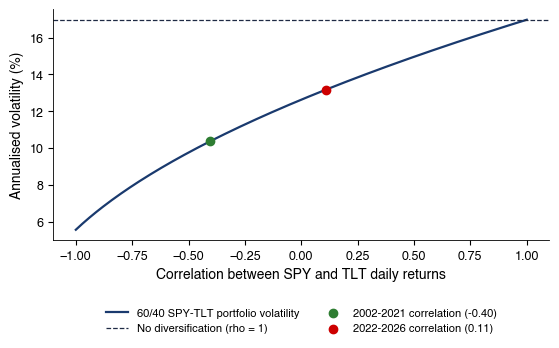

{'div_s_spy': 0.1878,
 'div_s_tlt': 0.1426,
 'div_rho_pre': np.float64(-0.4033),
 'div_rho_post': np.float64(0.1101),
 'div_vol_pre': np.float64(0.1037),
 'div_vol_post': np.float64(0.1318),
 'div_vol_undiv': 0.1697,
 'div_vol_zero': np.float64(0.1263)}

In [5]:
def fig_diversification():
    R = joint_returns(['spy', 'tlt'])
    s1, s2 = R.std() * np.sqrt(252)
    w = 0.6
    rho = np.linspace(-1, 1, 201)
    vol = np.sqrt(w ** 2 * s1 ** 2 + (1 - w) ** 2 * s2 ** 2 + 2 * w * (1 - w) * rho * s1 * s2)
    r_pre = R.loc[:'2021-12-31'].corr().iloc[0, 1]
    r_post = R.loc['2022-01-01':].corr().iloc[0, 1]
    v = lambda r: np.sqrt(w ** 2 * s1 ** 2 + (1 - w) ** 2 * s2 ** 2 + 2 * w * (1 - w) * r * s1 * s2)
    fig, ax = plt.subplots(figsize=(6.4, 3.0))
    ax.plot(rho, 100 * vol, color=MainBlue, lw=1.6, label='60/40 SPY-TLT portfolio volatility')
    ax.axhline(100 * (w * s1 + (1 - w) * s2), color=Gray, ls='--', lw=0.9, label='No diversification (rho = 1)')
    ax.scatter([r_pre], [100 * v(r_pre)], color=Forest, zorder=5, s=36, label=f'2002-2021 correlation ({r_pre:.2f})')
    ax.scatter([r_post], [100 * v(r_post)], color=IDAred, zorder=5, s=36, label=f'2022-2026 correlation ({r_post:.2f})')
    ax.set_xlabel('Correlation between SPY and TLT daily returns')
    ax.set_ylabel('Annualised volatility (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.25)
    save_fig('ch6_diversification')
    NUM.update(div_s_spy=s1, div_s_tlt=s2, div_rho_pre=r_pre, div_rho_post=r_post, div_vol_pre=v(r_pre),
               div_vol_post=v(r_post), div_vol_undiv=w * s1 + (1 - w) * s2, div_vol_zero=v(0.0),
               div_start=str(R.index[0].date()), div_n=len(R))


fig_diversification()
{k: round(v, 4) for k, v in NUM.items() if k.startswith('div') and isinstance(v, float)}

## 2. The stock–bond correlation changed sign

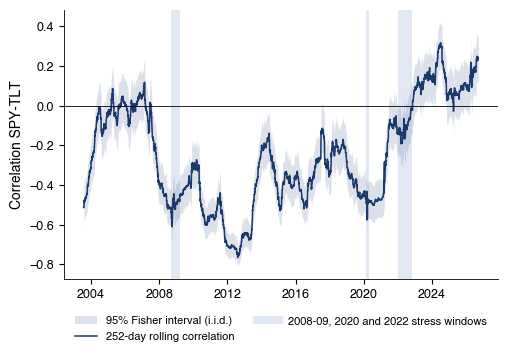

{'roll_min': -0.7652453273646802,
 'roll_min_date': '2012-08-08',
 'roll_max': 0.3161377668268076,
 'roll_max_date': '2024-07-01',
 'roll_last': np.float64(0.2438154736955139),
 'roll_last_date': '2026-09-18',
 'roll_share_pos_pre': np.float64(0.06465517241379311),
 'roll_share_pos_post': np.float64(0.8147208121827412),
 'roll_2022': np.float64(0.083434627120503)}

In [6]:
def fig_spy_tlt_rolling():
    R = joint_returns(['spy', 'tlt'])
    rc = rolling_corr(R, 252).dropna()
    lo, hi = fisher_ci(rc, 252)
    fig, ax = plt.subplots(figsize=SIDE)
    shade_crises(ax)
    ax.fill_between(rc.index, lo, hi, color=MainBlue, alpha=0.15, lw=0, label='95% Fisher interval (i.i.d.)')
    ax.plot(rc.index, rc, color=MainBlue, label='252-day rolling correlation')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Correlation SPY-TLT')
    ax.plot([], [], color=LightGray, alpha=0.5, lw=6, label='2008-09, 2020 and 2022 stress windows')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    save_fig('ch6_spy_tlt_rolling')
    NUM.update(roll_min=rc.min(), roll_min_date=str(rc.idxmin().date()), roll_max=rc.max(),
               roll_max_date=str(rc.idxmax().date()), roll_last=rc.iloc[-1], roll_last_date=str(rc.index[-1].date()),
               roll_share_pos_pre=(rc.loc[:'2021-12-31'] > 0).mean(), roll_share_pos_post=(rc.loc['2022-01-01':] > 0).mean(),
               roll_2022=rc.loc['2022-12-30':'2022-12-31'].iloc[-1] if len(rc.loc['2022-12-30':'2022-12-31']) else rc.loc[:'2022-12-31'].iloc[-1])


fig_spy_tlt_rolling()
{k: v for k, v in NUM.items() if k.startswith('roll')}

## 3. EWMA versus rolling windows

- $\Sigma_t=\lambda\Sigma_{t-1}+(1-\lambda)r_{t-1}r_{t-1}^\top$ (RiskMetrics).

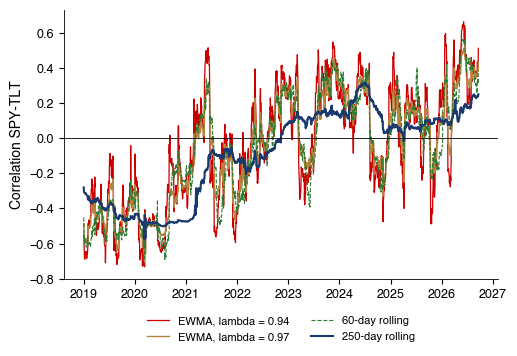

{'ew_date_prev': '2026-09-17',
 'ew_date': '2026-09-18',
 'ew_s11_prev': np.float64(0.39495817706985),
 'ew_s22_prev': np.float64(0.30725585885847684),
 'ew_s12_prev': np.float64(0.13930946113808443),
 'ew_r1': np.float64(1.1275070392483322),
 'ew_r2': np.float64(1.1066140224280652),
 'ew_s11': np.float64(0.4475370138589314),
 'ew_s22': np.float64(0.36229618300503363),
 'ew_s12': np.float64(0.20581379947091272),
 'ew_rho_prev': np.float64(0.3999032844120423),
 'ew_rho': np.float64(0.5111261856386572),
 'ew_sd94': 0.06036869804227452,
 'ew_sd97': 0.031716175311956474,
 'ew_sd250': 0.008817414474952198,
 'ew_halflife94': np.float64(11.202305583621158),
 'ew_halflife97': np.float64(22.75657306277341)}

In [7]:
def fig_ewma_rolling():
    R = joint_returns(['spy', 'tlt'])
    X = 100 * R
    e94 = ewma_corr(X, 0.94)
    e97 = ewma_corr(X, 0.97)
    r60 = rolling_corr(X, 60)
    r250 = rolling_corr(X, 250)
    sl = slice('2019-01-01', None)
    fig, ax = plt.subplots(figsize=SIDE)
    ax.plot(e94.loc[sl].index, e94.loc[sl], color=IDAred, lw=0.9, label='EWMA, lambda = 0.94')
    ax.plot(e97.loc[sl].index, e97.loc[sl], color=Amber, lw=1.0, label='EWMA, lambda = 0.97')
    ax.plot(r60.loc[sl].index, r60.loc[sl], color=Forest, lw=0.8, ls='--', label='60-day rolling')
    ax.plot(r250.loc[sl].index, r250.loc[sl], color=MainBlue, lw=1.5, label='250-day rolling')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Correlation SPY-TLT')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    save_fig('ch6_ewma_rolling')
    # step-by-step example: the last day of the sample
    S = ewma_cov(X.values, 0.94)
    t = len(X) - 1
    r = X.values[t - 1]
    NUM.update(ew_date_prev=str(X.index[t - 1].date()), ew_date=str(X.index[t].date()),
               ew_s11_prev=S[t - 1, 0, 0], ew_s22_prev=S[t - 1, 1, 1], ew_s12_prev=S[t - 1, 0, 1],
               ew_r1=r[0], ew_r2=r[1], ew_s11=S[t, 0, 0], ew_s22=S[t, 1, 1], ew_s12=S[t, 0, 1],
               ew_rho_prev=S[t - 1, 0, 1] / np.sqrt(S[t - 1, 0, 0] * S[t - 1, 1, 1]),
               ew_rho=S[t, 0, 1] / np.sqrt(S[t, 0, 0] * S[t, 1, 1]),
               ew_sd94=e94.loc[sl].diff().std(), ew_sd97=e97.loc[sl].diff().std(), ew_sd250=r250.loc[sl].diff().std(),
               ew_halflife94=np.log(0.5) / np.log(0.94), ew_halflife97=np.log(0.5) / np.log(0.97))


def first_persistent_positive(x, n=20):
    """First day after which the estimate stays positive for n consecutive days."""
    run = (x > 0).astype(int).rolling(n).sum()
    return run[run == n].index[0]


fig_ewma_rolling()
{k: v for k, v in NUM.items() if k.startswith('ew')}

## 4. Asynchronous trading: daily, 2-day and weekly correlations

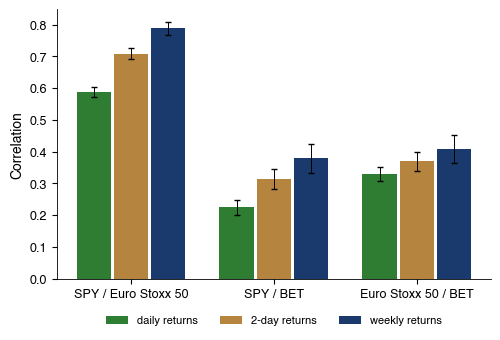

,pair,freq,rho,lo,hi,n
0,SPY / Euro Stoxx 50,daily,0.589,0.572,0.604,6446
1,SPY / Euro Stoxx 50,2-day,0.708,0.691,0.725,3223
2,SPY / Euro Stoxx 50,weekly,0.789,0.768,0.808,1367
3,SPY / Euro Stoxx 50,lead,0.202,NaN,NaN,6446
4,SPY / BET,daily,0.224,0.201,0.247,6446
5,SPY / BET,2-day,0.315,0.284,0.346,3223
6,SPY / BET,weekly,0.378,0.332,0.423,1367
7,SPY / BET,lead,0.169,NaN,NaN,6446
8,Euro Stoxx 50 / BET,daily,0.330,0.308,0.352,6446
9,Euro Stoxx 50 / BET,2-day,0.369,0.339,0.399,3223


In [8]:
def async_table():
    names = ['spy', 'stoxx', 'bet']
    P = joint_prices(names, start='2000-01-01')
    lp = np.log(P)
    d1 = lp.diff().dropna()
    d2 = (lp - lp.shift(2)).dropna().iloc[::2]                 # non-overlapping 2-day returns
    wk = np.log(P.resample('W-FRI').last()).diff().dropna()
    rows = []
    for a, b in (('spy', 'stoxx'), ('spy', 'bet'), ('stoxx', 'bet')):
        for lab, D in (('daily', d1), ('2-day', d2), ('weekly', wk)):
            r = D[a].corr(D[b])
            lo, hi = fisher_ci(r, len(D))
            rows.append(dict(pair=f'{SHORT[a]} / {SHORT[b]}', freq=lab, rho=r, lo=lo, hi=hi, n=len(D)))
        lead = d1[a].shift(1).corr(d1[b])                         # a yesterday -> b today
        rows.append(dict(pair=f'{SHORT[a]} / {SHORT[b]}', freq='lead', rho=lead, lo=np.nan, hi=np.nan, n=len(d1)))
    return pd.DataFrame(rows)


def fig_async():
    t = async_table()
    t.to_csv(os.path.join(TABLE_DIR, 'ch6_async_table.csv'), index=False, float_format='%.6g')
    pairs = t['pair'].unique()
    fig, ax = plt.subplots(figsize=SIDE)
    cols = {'daily': Forest, '2-day': Amber, 'weekly': MainBlue}
    for k, f in enumerate(['daily', '2-day', 'weekly']):
        s = t[t['freq'] == f].set_index('pair').loc[pairs]
        x = np.arange(len(pairs)) + (k - 1) * 0.26
        ax.bar(x, s['rho'], width=0.24, color=cols[f], label=f'{f} returns')
        ax.errorbar(x, s['rho'], yerr=[s['rho'] - s['lo'], s['hi'] - s['rho']], fmt='none', ecolor='black', lw=0.7, capsize=2)
    ax.set_xticks(np.arange(len(pairs)))
    ax.set_xticklabels(pairs)
    ax.set_ylabel('Correlation')
    legend_outside_bottom(ax, ncol=3, y=-0.1)
    save_fig('ch6_async')
    g = lambda p, f: float(t[(t.pair == p) & (t.freq == f)]['rho'].iloc[0])
    NUM.update(as_ss_d=g('SPY / Euro Stoxx 50', 'daily'), as_ss_2=g('SPY / Euro Stoxx 50', '2-day'),
               as_ss_w=g('SPY / Euro Stoxx 50', 'weekly'), as_ss_lead=g('SPY / Euro Stoxx 50', 'lead'),
               as_sb_d=g('SPY / BET', 'daily'), as_sb_w=g('SPY / BET', 'weekly'), as_sb_lead=g('SPY / BET', 'lead'),
               as_eb_d=g('Euro Stoxx 50 / BET', 'daily'), as_eb_w=g('Euro Stoxx 50 / BET', 'weekly'),
               as_n_d=int(t[t.freq == 'daily']['n'].iloc[0]), as_n_w=int(t[t.freq == 'weekly']['n'].iloc[0]))
    return t


fig_async().round(3)

## 5. DCC for SPY and TLT

- Step 1: GARCH(1,1) for each series; step 2: $(a,b)$ by maximum likelihood with $\bar Q$ fixed.

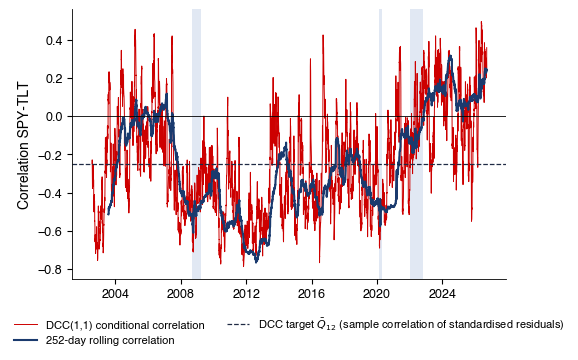

{'dcc_a': np.float64(0.05223189895883745),
 'dcc_b': np.float64(0.9335175039628505),
 'dcc_se_a': np.float64(0.005944150411891652),
 'dcc_se_b': np.float64(0.008353161045009647),
 'dcc_ab': np.float64(0.985749402921688),
 'dcc_hl': np.float64(48.292466730194114),
 'dcc_qbar': np.float64(-0.24848743687023794),
 'dcc_ll': np.float64(460.25932275802035),
 'dcc_ll_ccc': 193.5446870185861,
 'dcc_lr': np.float64(533.4292714788685),
 'dcc_min': -0.7862343013175003,
 'dcc_min_date': '2011-11-02',
 'dcc_max': 0.49442839562380453,
 'dcc_max_date': '2026-05-21',
 'dcc_last': np.float64(0.35837016016335754),
 'dcc_n': 6073,
 'dcc_start': '2002-07-31',
 'dcc_end': '2026-09-18',
 'g_spy_omega': np.float64(0.028313116613988425),
 'g_spy_alpha': np.float64(0.1265565043623981),
 'g_spy_beta': np.float64(0.8484421873054249),
 'g_tlt_omega': np.float64(0.0056900266788723715),
 'g_tlt_alpha': np.float64(0.0494475910421478),
 'g_tlt_beta': np.float64(0.9434396309238895),
 'dcc_mean_2008': np.float64(-0.536

In [9]:
def dcc_pair(names, start=None):
    R = joint_returns(names, start=start)
    P, V, Z, ll1 = garch_all(R)
    d = dcc_fit(Z)
    rc = pd.Series(d['R'][:, 0, 1], index=Z.index)
    return R, P, V, Z, d, rc, ll1


def fig_dcc_spy_tlt():
    R, P, V, Z, d, rc, ll1 = dcc_pair(['spy', 'tlt'])
    roll = rolling_corr(R, 252)
    fig, ax = plt.subplots(figsize=SIDE)
    shade_crises(ax)
    ax.plot(rc.index, rc, color=IDAred, lw=0.7, label='DCC(1,1) conditional correlation')
    ax.plot(roll.index, roll, color=MainBlue, lw=1.5, label='252-day rolling correlation')
    ax.axhline(d['Qbar'][0, 1], color=Gray, ls='--', lw=0.9, label='DCC target $\\bar Q_{12}$ (sample correlation of standardised residuals)')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Correlation SPY-TLT')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    save_fig('ch6_dcc_spy_tlt')
    lr = 2 * (d['loglik'] - d['ccc_loglik'])
    NUM.update(dcc_a=d['a'], dcc_b=d['b'], dcc_se_a=d['se_a'], dcc_se_b=d['se_b'], dcc_ab=d['a'] + d['b'],
               dcc_hl=np.log(0.5) / np.log(d['a'] + d['b']), dcc_qbar=d['Qbar'][0, 1], dcc_ll=d['loglik'],
               dcc_ll_ccc=d['ccc_loglik'], dcc_lr=lr, dcc_min=rc.min(), dcc_min_date=str(rc.idxmin().date()),
               dcc_max=rc.max(), dcc_max_date=str(rc.idxmax().date()), dcc_last=rc.iloc[-1], dcc_n=len(Z),
               dcc_start=str(Z.index[0].date()), dcc_end=str(Z.index[-1].date()),
               g_spy_omega=P.loc['omega', 'spy'], g_spy_alpha=P.loc['alpha[1]', 'spy'], g_spy_beta=P.loc['beta[1]', 'spy'],
               g_tlt_omega=P.loc['omega', 'tlt'], g_tlt_alpha=P.loc['alpha[1]', 'tlt'], g_tlt_beta=P.loc['beta[1]', 'tlt'],
               dcc_mean_2008=rc.loc['2008-09-15':'2008-12-31'].mean(), dcc_mean_2022=rc.loc['2022'].mean(),
               dcc_mean_2012=rc.loc['2012'].mean())
    return R, V, rc


R, V, rc = fig_dcc_spy_tlt()
{k: v for k, v in NUM.items() if k.startswith(('dcc', 'g_'))}

## 6. Minimum-variance weights with DCC

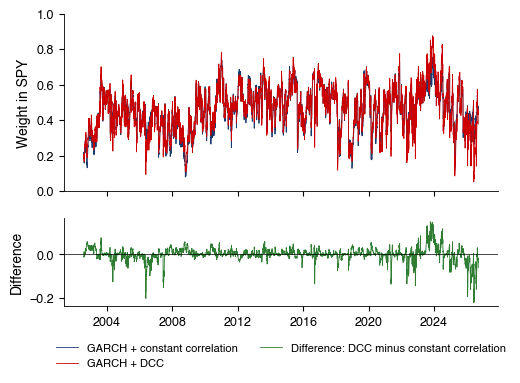

{'mv_vol_dcc': np.float64(9.059560950217332),
 'mv_vol_ccc': np.float64(9.103662389587193),
 'mv_vol_6040': np.float64(10.990729024815868),
 'mv_w_mean': np.float64(0.4627867899298926),
 'mv_w_2022': np.float64(0.4288175940430178),
 'mv_w_2012': np.float64(0.5349504123551014),
 'mv_dmax': 0.22090310075839859,
 'mv_dmax_date': '2026-06-08',
 'mv_dmean': np.float64(0.018585028336968103),
 'mv_rho0': np.float64(-0.3000242676861273)}

In [10]:
def fig_dcc_minvar(R, V, rc):
    """SPY weight in the SPY-TLT minimum-variance portfolio: DCC vs constant correlation."""
    s1, s2 = V['spy'], V['tlt']
    c = rc * s1 * s2
    w_dcc = ((s2 ** 2 - c) / (s1 ** 2 + s2 ** 2 - 2 * c)).clip(0, 1)
    rho0 = R.corr().iloc[0, 1]
    c0 = rho0 * s1 * s2
    w_ccc = ((s2 ** 2 - c0) / (s1 ** 2 + s2 ** 2 - 2 * c0)).clip(0, 1)
    # simple asset returns (R holds log returns): the portfolio return is sum_i w_i (e^{r_i} - 1)
    X = 100 * np.expm1(R.loc[w_dcc.index])
    # the filters (GARCH volatilities, R_t) use only information up to day t-1, but the GARCH, DCC and
    # constant-correlation parameters are estimated on the full sample: an IN-sample illustration, not an out-of-sample evaluation
    p_dcc = w_dcc * X['spy'] + (1 - w_dcc) * X['tlt']
    p_ccc = w_ccc * X['spy'] + (1 - w_ccc) * X['tlt']
    p_6040 = 0.6 * X['spy'] + 0.4 * X['tlt']
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(5.6, 3.8), sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
    ax.plot(w_ccc.index, w_ccc, color=MainBlue, lw=0.6, label='GARCH + constant correlation')
    ax.plot(w_dcc.index, w_dcc, color=IDAred, lw=0.6, label='GARCH + DCC')
    ax.set_ylabel('Weight in SPY')
    ax.set_ylim(0, 1)
    ax2.plot(w_dcc.index, w_dcc - w_ccc, color=Forest, lw=0.6, label='Difference: DCC minus constant correlation')
    ax2.axhline(0, color='black', lw=0.5)
    ax2.set_ylabel('Difference')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
    save_fig('ch6_dcc_minvar')
    ann = lambda p: p.std() * np.sqrt(252)
    NUM.update(mv_vol_dcc=ann(p_dcc), mv_vol_ccc=ann(p_ccc), mv_vol_6040=ann(p_6040),
               mv_w_mean=w_dcc.mean(), mv_w_2022=w_dcc.loc['2022'].mean(), mv_w_2012=w_dcc.loc['2012'].mean(),
               mv_dmax=(w_dcc - w_ccc).abs().max(), mv_dmax_date=str((w_dcc - w_ccc).abs().idxmax().date()),
               mv_dmean=(w_dcc - w_ccc).abs().mean(), mv_rho0=rho0)


fig_dcc_minvar(R, V, rc)
{k: v for k, v in NUM.items() if k.startswith('mv')}

## 7. Bitcoin and US equities

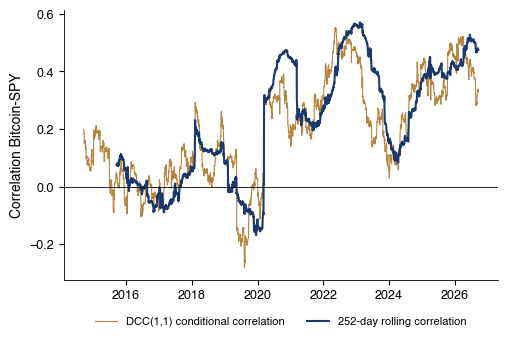

{'btc_a': np.float64(0.014631418245784723),
 'btc_b': np.float64(0.9821947504290968),
 'btc_se_a': np.float64(0.003686168047957329),
 'btc_se_b': np.float64(0.005012891327662845),
 'btc_ab': np.float64(0.9968261686748815),
 'btc_lr': np.float64(105.61003527258494),
 'btc_n': 3018,
 'btc_start': '2014-09-18',
 'btc_pre2020': np.float64(0.04321934136015081),
 'btc_post2020': np.float64(0.3124186768428943),
 'btc_2022': np.float64(0.46117432308346046),
 'btc_max': 0.5525360752310905,
 'btc_max_date': '2022-05-19',
 'btc_last': np.float64(0.32935052387779457),
 'btc_uncond': np.float64(0.23705562896394028)}

In [11]:
def fig_dcc_btc_spy():
    R, P, V, Z, d, rc, ll1 = dcc_pair(['btc', 'spy'])
    roll = rolling_corr(R, 252)
    fig, ax = plt.subplots(figsize=SIDE)
    ax.plot(rc.index, rc, color=Amber, lw=0.8, label='DCC(1,1) conditional correlation')
    ax.plot(roll.index, roll, color=MainBlue, lw=1.5, label='252-day rolling correlation')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Correlation Bitcoin-SPY')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    save_fig('ch6_dcc_btc_spy')
    yr = rc.groupby(rc.index.year).mean()
    NUM.update(btc_a=d['a'], btc_b=d['b'], btc_se_a=d['se_a'], btc_se_b=d['se_b'], btc_ab=d['a'] + d['b'],
               btc_lr=2 * (d['loglik'] - d['ccc_loglik']), btc_n=len(Z), btc_start=str(Z.index[0].date()),
               btc_pre2020=rc.loc[:'2019-12-31'].mean(), btc_post2020=rc.loc['2020-01-01':].mean(),
               btc_2022=yr.loc[2022], btc_max=rc.max(), btc_max_date=str(rc.idxmax().date()),
               btc_last=rc.iloc[-1], btc_uncond=R.corr().iloc[0, 1])


fig_dcc_btc_spy()
{k: v for k, v in NUM.items() if k.startswith('btc')}

## 8. Crisis correlations: the Forbes–Rigobon adjustment

- $\rho^*=\rho_c/\sqrt{1+\delta(1-\rho_c^2)}$, 2-day returns.

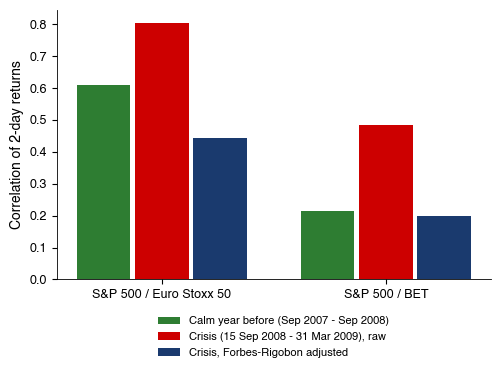

        rho_calm  rho_crisis  delta  rho_adj  z_raw  p_raw  z_adj  p_adj  \
target                                                                     
stoxx      0.610       0.804  6.544    0.442  2.564  0.005 -1.491  0.932   
bet        0.216       0.485  6.544    0.198  1.975  0.024 -0.122  0.548   

        n_calm  n_crisis  
target                    
stoxx      242       130  
bet        242       130  


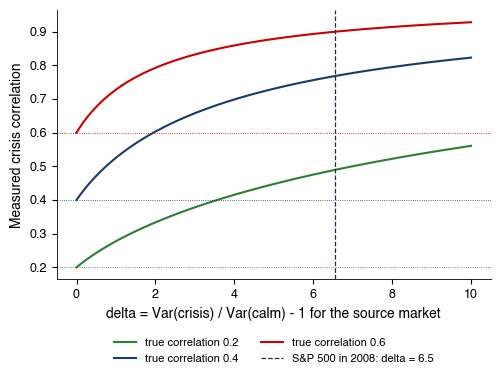

In [12]:
CALM08, CRISIS08 = ('2007-09-14', '2008-09-12'), ('2008-09-15', '2009-03-31')
CALM20, CRISIS20 = ('2019-02-19', '2020-02-19'), ('2020-02-20', '2020-04-30')


def two_day_returns(names, start='2006-01-01', end='2021-12-31'):
    """2-day returns (moving sum, as in Forbes-Rigobon): log p_t - log p_{t-2}, from common prices."""
    lp = np.log(joint_prices(names, start=start, end=end))
    return (lp - lp.shift(2)).dropna()


def fig_forbes_rigobon():
    r2 = two_day_returns(['sp500', 'stoxx', 'bet'])
    t = crisis_table(r2, 'sp500', ['stoxx', 'bet'], CALM08, CRISIS08)
    t.to_csv(os.path.join(TABLE_DIR, 'ch6_forbes_rigobon_2008.csv'), float_format='%.6g')
    fig, ax = plt.subplots(figsize=SIDE)
    x = np.arange(len(t))
    ax.bar(x - 0.26, t['rho_calm'], 0.24, color=Forest, label='Calm year before (Sep 2007 - Sep 2008)')
    ax.bar(x, t['rho_crisis'], 0.24, color=IDAred, label='Crisis (15 Sep 2008 - 31 Mar 2009), raw')
    ax.bar(x + 0.26, t['rho_adj'], 0.24, color=MainBlue, label='Crisis, Forbes-Rigobon adjusted')
    ax.set_xticks(x)
    ax.set_xticklabels([f'S&P 500 / {SHORT[k]}' for k in t.index])
    ax.set_ylabel('Correlation of 2-day returns')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch6_forbes_rigobon')
    for k in t.index:
        for c in ('rho_calm', 'rho_crisis', 'rho_adj', 'z_raw', 'p_raw', 'z_adj', 'p_adj'):
            NUM[f'fr_{k}_{c}'] = t.loc[k, c]
    NUM.update(fr_delta=t['delta'].iloc[0], fr_n_calm=int(t['n_calm'].iloc[0]), fr_n_crisis=int(t['n_crisis'].iloc[0]),
               fr_vr=1 + t['delta'].iloc[0])
    return t


def fig_fr_bias():
    delta = np.linspace(0, 10, 201)
    fig, ax = plt.subplots(figsize=SIDE)
    for rho, c in ((0.2, Forest), (0.4, MainBlue), (0.6, IDAred)):
        ax.plot(delta, fr_inflation(rho, delta), color=c, lw=1.5, label=f'true correlation {rho}')
        ax.axhline(rho, color=c, lw=0.6, ls=':')
    ax.axvline(NUM['fr_delta'], color=Gray, ls='--', lw=0.9, label=f'S&P 500 in 2008: delta = {NUM["fr_delta"]:.1f}')
    ax.set_xlabel('delta = Var(crisis) / Var(calm) - 1 for the source market')
    ax.set_ylabel('Measured crisis correlation')
    legend_outside_bottom(ax, ncol=2, y=-0.18)
    save_fig('ch6_fr_bias')
    NUM.update(frb_04=fr_inflation(0.4, NUM['fr_delta']), frb_02=fr_inflation(0.2, NUM['fr_delta']))


print(fig_forbes_rigobon().round(3))
fig_fr_bias()

## 9. Exceedance correlations

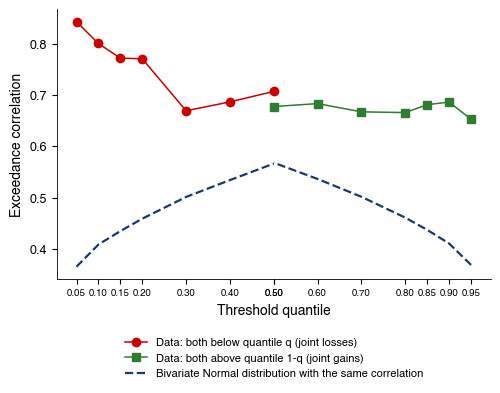

{'ex_rho': np.float64(0.7808002980939122),
 'ex_n': 1393,
 'ex_low10': np.float64(0.8003090135214949),
 'ex_high10': np.float64(0.6861620013495532),
 'ex_nlow10': 86,
 'ex_nhigh10': 70,
 'ex_norm10': np.float64(0.4086607396342757),
 'ex_low20': np.float64(0.7705058928229434),
 'ex_high20': np.float64(0.6657428546954386),
 'ex_norm20': np.float64(0.4590644676973544)}

In [13]:
def fig_exceedance():
    W = weekly_returns(['sp500', 'stoxx'], start='2000-01-01')
    x, y = W['sp500'].values, W['stoxx'].values
    qs = np.array([0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50])
    e = exceedance_corr(x, y, qs)
    rho = np.corrcoef(x, y)[0, 1]
    rng = np.random.default_rng(SEED)
    Zs = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], 2_000_000)
    en = exceedance_corr(Zs[:, 0], Zs[:, 1], qs)
    fig, ax = plt.subplots(figsize=SIDE)
    xl = np.concatenate([qs, 1 - qs[::-1]])
    ax.plot(qs, e['rho_low'], 'o-', color=IDAred, label='Data: both below quantile q (joint losses)')
    ax.plot(1 - qs, e['rho_high'], 's-', color=Forest, label='Data: both above quantile 1-q (joint gains)')
    ax.plot(qs, en['rho_low'], color=MainBlue, ls='--', lw=1.6, label='Bivariate Normal distribution with the same correlation')
    ax.plot(1 - qs, en['rho_high'], color=MainBlue, ls='--', lw=1.6)
    ax.set_xticks(xl)
    ax.set_xticklabels([f'{v:.2f}' for v in xl], fontsize=7)
    ax.set_xlabel('Threshold quantile')
    ax.set_ylabel('Exceedance correlation')
    legend_outside_bottom(ax, ncol=1, y=-0.18)
    save_fig('ch6_exceedance')
    e.to_csv(os.path.join(TABLE_DIR, 'ch6_exceedance.csv'), float_format='%.6g')
    NUM.update(ex_rho=rho, ex_n=len(W), ex_low10=e.loc[0.10, 'rho_low'], ex_high10=e.loc[0.10, 'rho_high'],
               ex_nlow10=int(e.loc[0.10, 'n_low']), ex_nhigh10=int(e.loc[0.10, 'n_high']),
               ex_norm10=en.loc[0.10, 'rho_low'], ex_low20=e.loc[0.20, 'rho_low'], ex_high20=e.loc[0.20, 'rho_high'],
               ex_norm20=en.loc[0.20, 'rho_low'])


fig_exceedance()
{k: v for k, v in NUM.items() if k.startswith('ex')}

## 10. Five copulas with the same Kendall's tau

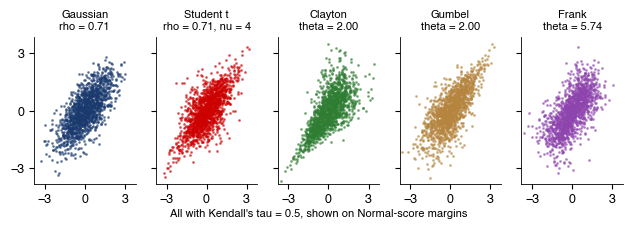

{'zoo_gaussian': np.float64(0.7071),
 'zoo_gaussian_lamL': 0.0,
 'zoo_gaussian_lamU': 0.0,
 'zoo_t': np.float64(0.7071),
 'zoo_t_lamL': np.float64(0.3968),
 'zoo_t_lamU': np.float64(0.3968),
 'zoo_clayton': 2.0,
 'zoo_clayton_lamL': 0.7071,
 'zoo_clayton_lamU': 0.0,
 'zoo_gumbel': 2.0,
 'zoo_gumbel_lamL': 0.0,
 'zoo_gumbel_lamU': 0.5858,
 'zoo_frank': 5.7363,
 'zoo_frank_lamL': 0.0,
 'zoo_frank_lamU': 0.0}

In [14]:
def fig_copula_zoo(tau=0.5, n=1500):
    rng = np.random.default_rng(SEED)
    fig, axes = plt.subplots(1, 5, figsize=(7.6, 1.9), sharex=True, sharey=True)
    for ax, fam in zip(axes, FAMILIES):
        th = theta_from_tau(fam, tau)
        par = [th, 4.0] if fam == 't' else [th]
        X = simulate(fam, par, n, rng)
        Zs = stats.norm.ppf(X)
        ax.scatter(Zs[:, 0], Zs[:, 1], s=1.2, color=FAM_COL[fam], alpha=0.5)
        lab = f'{FAM_LABEL[fam]}\n' + (f'rho = {th:.2f}, nu = 4' if fam == 't' else (f'rho = {th:.2f}' if fam == 'gaussian' else f'theta = {th:.2f}'))
        ax.set_title(lab, fontsize=8)
        ax.set_xlim(-3.8, 3.8)
        ax.set_ylim(-3.8, 3.8)
        ax.set_xticks([-3, 0, 3])
        ax.set_yticks([-3, 0, 3])
    fig.text(0.5, -0.06, "All with Kendall's tau = 0.5, shown on Normal-score margins", ha='center', fontsize=8)
    save_fig('ch6_copula_zoo')
    for fam in FAMILIES:
        th = theta_from_tau(fam, tau)
        NUM[f'zoo_{fam}'] = th
        lam = tail_dep(fam, [th, 4.0] if fam == 't' else [th])
        NUM[f'zoo_{fam}_lamL'], NUM[f'zoo_{fam}_lamU'] = lam


fig_copula_zoo()
{k: round(v, 4) for k, v in NUM.items() if k.startswith('zoo')}

## 11. Copulas for JPM and BAC

- GARCH filter, pseudo-observations, canonical maximum likelihood, AIC, goodness of fit (a few minutes).

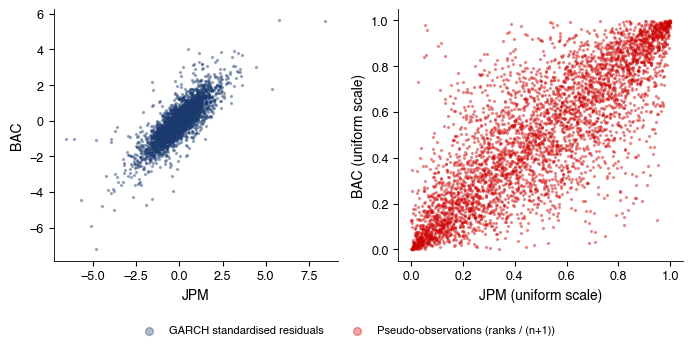

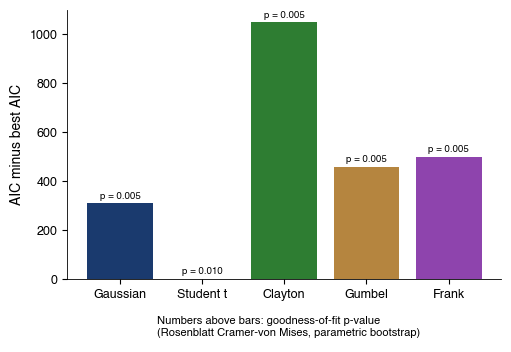

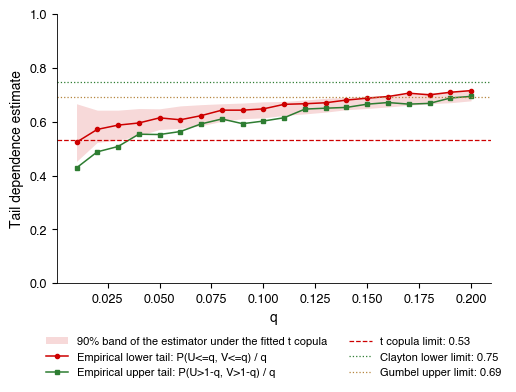

,par1,par2,loglik,aic,bic,tau_model,lamL,lamU,gof_stat,gof_p,gof_B
family,,,,,,,,,,,
gaussian,0.833,NaN,2486.019,-4970.038,-4963.695,0.627,0.000,0.000,0.968,0.005,200
t,0.842,4.241,2641.675,-5279.350,-5266.663,0.637,0.531,0.531,0.082,0.010,100
clayton,2.384,NaN,2116.660,-4231.320,-4224.977,0.544,0.748,0.000,1.243,0.005,200
gumbel,2.587,NaN,2412.239,-4822.478,-4816.135,0.613,0.000,0.693,1.418,0.005,200
frank,9.152,NaN,2390.764,-4779.528,-4773.184,0.641,0.000,0.000,0.365,0.005,200


In [15]:
def bank_copula_data():
    R = joint_returns(['jpm', 'bac'])
    P, V, Z, ll = garch_all(R)
    U = pseudo_obs(Z.values)
    return R, Z, U


def fig_pseudo_obs(Z, U):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))
    axes[0].scatter(Z['jpm'], Z['bac'], s=2, color=MainBlue, alpha=0.35, label='GARCH standardised residuals')
    axes[0].set_xlabel('JPM')
    axes[0].set_ylabel('BAC')
    axes[1].scatter(U[:, 0], U[:, 1], s=2, color=IDAred, alpha=0.35, label='Pseudo-observations (ranks / (n+1))')
    axes[1].set_xlabel('JPM (uniform scale)')
    axes[1].set_ylabel('BAC (uniform scale)')
    h = [axes[0].collections[0], axes[1].collections[0]]
    fig.legend(h, [x.get_label() for x in h], loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False,
               markerscale=4)
    plt.tight_layout()
    save_fig('ch6_pseudo_obs')


def copula_table(U, B=200, B_t=100):
    u, v = U[:, 0], U[:, 1]
    rows = []
    for fam in FAMILIES:
        f = fit_copula(fam, u, v)
        g = gof_test(fam, u, v, B=B_t if fam == 't' else B, seed=SEED, fit=f)
        rows.append(dict(family=fam, par1=f['par'][0], par2=f['par'][1] if fam == 't' else np.nan, loglik=f['loglik'],
                         aic=f['aic'], bic=f['bic'], tau_model=f['tau_model'], lamL=f['lamL'], lamU=f['lamU'],
                         gof_stat=g['stat'], gof_p=g['p'], gof_B=g['B']))
    return pd.DataFrame(rows).set_index('family')


def fig_copula_fit(U):
    t = copula_table(U)
    t.to_csv(os.path.join(TABLE_DIR, 'ch6_copula_jpm_bac.csv'), float_format='%.6g')
    fig, ax = plt.subplots(figsize=SIDE)
    d = t['aic'] - t['aic'].min()
    ax.bar(np.arange(5), d, color=[FAM_COL[f] for f in t.index])
    for i, (fam, val) in enumerate(d.items()):
        ax.text(i, val + d.max() * 0.02, f'p = {t.loc[fam, "gof_p"]:.3f}', ha='center', fontsize=7)
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels([FAM_LABEL[f] for f in t.index])
    ax.set_ylabel('AIC minus best AIC')
    ax.plot([], [], ' ', label='Numbers above bars: goodness-of-fit p-value\n(Rosenblatt Cramer-von Mises, parametric bootstrap)')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=1, frameon=False, handlelength=0)
    save_fig('ch6_copula_fit')
    u, v = U[:, 0], U[:, 1]
    NUM.update(cop_n=len(U), cop_tau=kendall_tau(u, v), cop_rhoS=spearman_rho(u, v))
    for fam in t.index:
        for c in ('par1', 'par2', 'loglik', 'aic', 'lamL', 'lamU', 'gof_stat', 'gof_p', 'tau_model'):
            NUM[f'cop_{fam}_{c}'] = t.loc[fam, c]
        NUM[f'cop_{fam}_daic'] = d[fam]
    NUM['cop_best'] = t['aic'].idxmin()
    return t


def fig_tail_dep(U, t):
    u, v = U[:, 0], U[:, 1]
    qs = np.linspace(0.01, 0.20, 20)
    emp = np.array([empirical_tail_dep(u, v, q) for q in qs])
    rng = np.random.default_rng(SEED)
    # reference band: the same estimate on data simulated from the fitted t copula (200 replications)
    par_t = [t.loc['t', 'par1'], t.loc['t', 'par2']]
    sims = []
    for _ in range(200):
        X = pseudo_obs(simulate('t', par_t, len(u), rng))
        sims.append([empirical_tail_dep(X[:, 0], X[:, 1], q)[0] for q in qs])
    sims = np.array(sims)
    fig, ax = plt.subplots(figsize=SIDE)
    ax.fill_between(qs, np.percentile(sims, 5, axis=0), np.percentile(sims, 95, axis=0), color=IDAred, alpha=0.15, lw=0,
                    label='90% band of the estimator under the fitted t copula')
    ax.plot(qs, emp[:, 0], 'o-', ms=3, color=IDAred, label='Empirical lower tail: P(U<=q, V<=q) / q')
    ax.plot(qs, emp[:, 1], 's-', ms=3, color=Forest, label='Empirical upper tail: P(U>1-q, V>1-q) / q')
    ax.axhline(t.loc['t', 'lamL'], color=IDAred, ls='--', lw=0.9, label=f't copula limit: {t.loc["t", "lamL"]:.2f}')
    ax.axhline(t.loc['clayton', 'lamL'], color=Forest, ls=':', lw=0.9, label=f'Clayton lower limit: {t.loc["clayton", "lamL"]:.2f}')
    ax.axhline(t.loc['gumbel', 'lamU'], color=Amber, ls=':', lw=0.9, label=f'Gumbel upper limit: {t.loc["gumbel", "lamU"]:.2f}')
    ax.set_xlabel('q')
    ax.set_ylabel('Tail dependence estimate')
    ax.set_ylim(0, 1)
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch6_tail_dep')
    i5 = np.argmin(np.abs(qs - 0.05))
    NUM.update(td_L05=emp[i5, 0], td_U05=emp[i5, 1], td_L01=emp[0, 0], td_U01=emp[0, 1],
               td_band05_lo=np.percentile(sims[:, i5], 5), td_band05_hi=np.percentile(sims[:, i5], 95))


Rb, Zb, Ub = bank_copula_data()
fig_pseudo_obs(Zb, Ub)
tb = fig_copula_fit(Ub)
fig_tail_dep(Ub, tb)
tb.round(3)

## 12. US, euro-area and Romanian equities

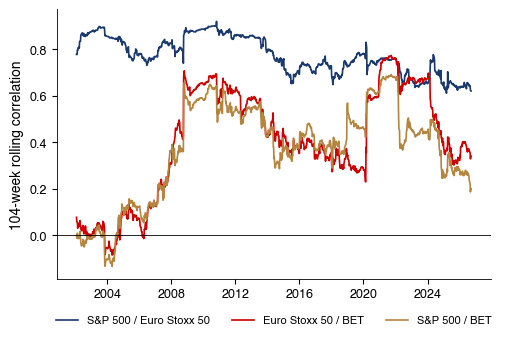

{'int_sp500_stoxx_pre': np.float64(0.781),
 'int_sp500_stoxx_post': np.float64(0.701),
 'int_sp500_stoxx_00s': np.float64(0.84),
 'int_stoxx_bet_pre': np.float64(0.448),
 'int_stoxx_bet_post': np.float64(0.615),
 'int_stoxx_bet_00s': np.float64(0.327),
 'int_sp500_bet_pre': np.float64(0.468),
 'int_sp500_bet_post': np.float64(0.487),
 'int_sp500_bet_00s': np.float64(0.298)}

In [16]:
def fig_integration():
    W = weekly_returns(['sp500', 'stoxx', 'bet'], start='2000-01-01')
    win = 104
    fig, ax = plt.subplots(figsize=SIDE)
    for (a, b), c in ((('sp500', 'stoxx'), MainBlue), (('stoxx', 'bet'), IDAred), (('sp500', 'bet'), Amber)):
        rc = W[a].rolling(win).corr(W[b])
        ax.plot(rc.index, rc, color=c, lw=1.2, label=f'{SHORT[a]} / {SHORT[b]}')
        NUM[f'int_{a}_{b}_pre'] = W.loc['2010-01-01':'2019-12-31', a].corr(W.loc['2010-01-01':'2019-12-31', b])
        NUM[f'int_{a}_{b}_post'] = W.loc['2020-01-01':, a].corr(W.loc['2020-01-01':, b])
        NUM[f'int_{a}_{b}_00s'] = W.loc[:'2009-12-31', a].corr(W.loc[:'2009-12-31', b])
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('104-week rolling correlation')
    legend_outside_bottom(ax, ncol=3, y=-0.1)
    save_fig('ch6_integration')
    NUM.update(int_n=len(W), int_start=str(W.index[0].date()))


fig_integration()
{k: round(v, 3) for k, v in NUM.items() if k.startswith('int') and isinstance(v, float)}

## 13. Banks: correlations, averages over time and a minimum spanning tree

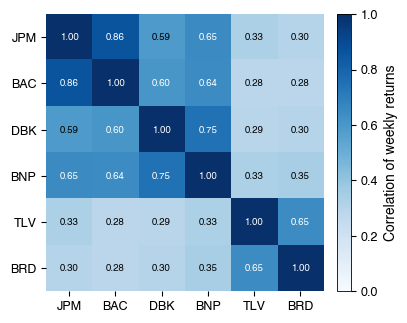

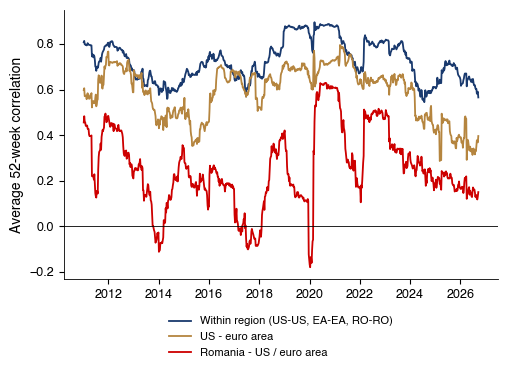

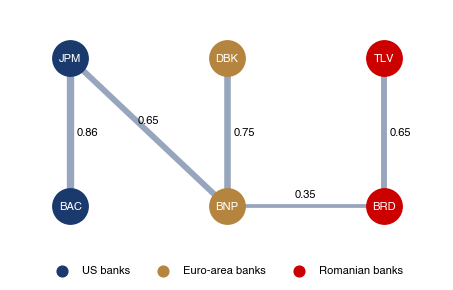

{'bk_within_mean': np.float64(0.7255881816980272),
 'bk_within_2020': np.float64(0.8736261472715958),
 'bk_within_last': np.float64(0.5653573733033096),
 'bk_useu_mean': np.float64(0.5880168046267021),
 'bk_useu_2020': np.float64(0.6871915394653648),
 'bk_useu_last': np.float64(0.3959880515724668),
 'bk_ro_mean': np.float64(0.2522056748020621),
 'bk_ro_2020': np.float64(0.55750253989939),
 'bk_ro_last': np.float64(0.15007355136517422),
 'bk_n': 871,
 'bk_start': '2010-01-15',
 'bk_jpm_bac': np.float64(0.8606223701055454),
 'bk_dbk_bnp': np.float64(0.7476526655377106),
 'bk_tlv_brd': np.float64(0.6474184337774924),
 'bk_bnp_tlv': np.float64(0.3289217804781948),
 'bk_jpm_brd': np.float64(0.3033204269435855),
 'bk_mst_edges': 'JPM--BAC (0.86); JPM--BNP (0.65); DBK--BNP (0.75); BNP--BRD (0.35); TLV--BRD (0.65)',
 'bk_bridge': ['BNP--BRD']}

In [17]:
def fig_banks():
    W = weekly_returns(BANKS, start='2010-01-01')
    C = W.corr()
    C.to_csv(os.path.join(TABLE_DIR, 'ch6_banks_corr.csv'), float_format='%.6g')
    lab = [SHORT[b] for b in BANKS]
    fig, ax = plt.subplots(figsize=(4.4, 3.6))
    im = ax.imshow(C.values, cmap='Blues', vmin=0, vmax=1)
    for i in range(6):
        for j in range(6):
            ax.text(j, i, f'{C.values[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if C.values[i, j] > 0.6 else 'black')
    ax.set_xticks(range(6))
    ax.set_xticklabels(lab)
    ax.set_yticks(range(6))
    ax.set_yticklabels(lab)
    for s in ax.spines.values():
        s.set_visible(False)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Correlation of weekly returns')
    save_fig('ch6_banks_heatmap')
    # 52-week average correlation: within the same region vs across regions
    region = {'jpm': 'US', 'bac': 'US', 'dbk': 'EA', 'bnp': 'EA', 'tlv': 'RO', 'brd': 'RO'}
    pairs = [(a, b) for i, a in enumerate(BANKS) for b in BANKS[i + 1:]]
    rc = {p: W[p[0]].rolling(52).corr(W[p[1]]) for p in pairs}
    grp = {'Within region (US-US, EA-EA, RO-RO)': [p for p in pairs if region[p[0]] == region[p[1]]],
           'US - euro area': [p for p in pairs if {region[p[0]], region[p[1]]} == {'US', 'EA'}],
           'Romania - US / euro area': [p for p in pairs if 'RO' in (region[p[0]], region[p[1]]) and region[p[0]] != region[p[1]]]}
    fig, ax = plt.subplots(figsize=SIDE)
    for (g, ps), c in zip(grp.items(), (MainBlue, Amber, IDAred)):
        m = pd.concat([rc[p] for p in ps], axis=1).mean(axis=1)
        ax.plot(m.index, m, color=c, lw=1.3, label=g)
        NUM[f'bk_{["within", "useu", "ro"][list(grp).index(g)]}_mean'] = m.mean()
        NUM[f'bk_{["within", "useu", "ro"][list(grp).index(g)]}_2020'] = m.loc['2020-03-01':'2020-06-30'].mean()
        NUM[f'bk_{["within", "useu", "ro"][list(grp).index(g)]}_last'] = m.dropna().iloc[-1]
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Average 52-week correlation')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch6_banks_avgcorr')
    # minimum spanning tree on the distance d = sqrt(2(1 - rho)) (Mantegna, 1999)
    G = nx.Graph()
    for a, b in pairs:
        G.add_edge(SHORT[a], SHORT[b], weight=np.sqrt(2 * (1 - C.loc[a, b])), rho=C.loc[a, b])
    T = nx.minimum_spanning_tree(G)
    pos = {'JPM': (-1.0, 0.6), 'BAC': (-1.0, -0.6), 'DBK': (0.3, 0.6), 'BNP': (0.3, -0.6), 'TLV': (1.6, 0.6), 'BRD': (1.6, -0.6)}
    colr = {'JPM': MainBlue, 'BAC': MainBlue, 'DBK': Amber, 'BNP': Amber, 'TLV': IDAred, 'BRD': IDAred}
    fig, ax = plt.subplots(figsize=(5.6, 3.2))
    for a, b, dd in T.edges(data=True):
        ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color=MainBlue, alpha=0.45, lw=1 + 5 * dd['rho'], zorder=1)
        vert = pos[a][0] == pos[b][0]
        ax.text((pos[a][0] + pos[b][0]) / 2 + (0.14 if vert else 0), (pos[a][1] + pos[b][1]) / 2 + (0 if vert else 0.1),
                f'{dd["rho"]:.2f}', ha='center', va='center', fontsize=8)
    for k, (x, y) in pos.items():
        ax.scatter(x, y, s=650, color=colr[k], zorder=2)
        ax.text(x, y, k, color='white', ha='center', va='center', fontsize=8, fontweight='bold', zorder=3)
    for lab_, c in (('US banks', MainBlue), ('Euro-area banks', Amber), ('Romanian banks', IDAred)):
        ax.scatter([], [], s=60, color=c, label=lab_)
    ax.set_xlim(-1.5, 2.1)
    ax.set_ylim(-1.0, 1.0)
    ax.axis('off')
    legend_outside_bottom(ax, ncol=3, y=0.0)
    save_fig('ch6_banks_mst')
    NUM.update(bk_n=len(W), bk_start=str(W.index[0].date()), bk_jpm_bac=C.loc['jpm', 'bac'], bk_dbk_bnp=C.loc['dbk', 'bnp'],
               bk_tlv_brd=C.loc['tlv', 'brd'], bk_bnp_tlv=C.loc['bnp', 'tlv'], bk_jpm_brd=C.loc['jpm', 'brd'],
               bk_mst_edges='; '.join(f'{a}--{b} ({d["rho"]:.2f})' for a, b, d in T.edges(data=True)))
    # the link between regions in the tree
    NUM['bk_bridge'] = [f'{a}--{b}' for a, b, d in T.edges(data=True) if {a, b} & {'TLV', 'BRD'} and not {a, b} <= {'TLV', 'BRD'}]


fig_banks()
{k: v for k, v in NUM.items() if k.startswith('bk')}

## 14. Inference on a correlation: HAC intervals and a break at an unknown date

- Delta method on the moments $(x, y, x^2, y^2, xy)$ with a Bartlett HAC covariance.
- Wied–Krämer–Dehling test on GARCH-standardised residuals (bandwidth $\lfloor T^{1/4}\rfloor$).

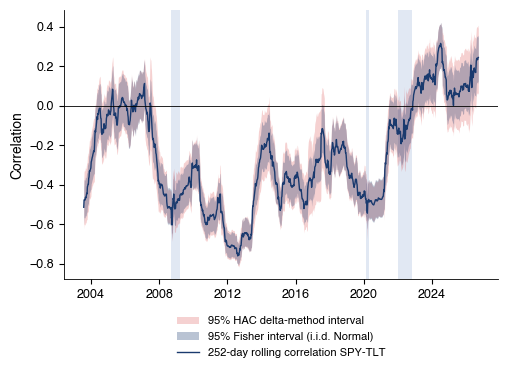

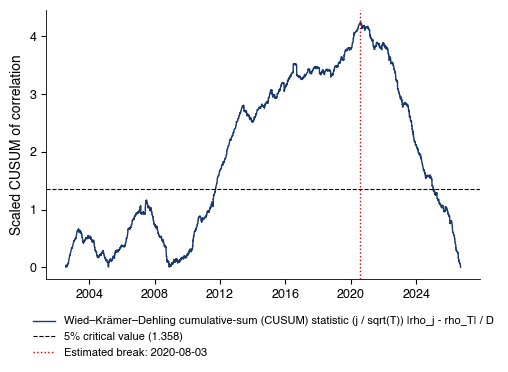

{'hac_ratio_med': 1.242572989275828,
 'hac_ratio_q90': np.float64(1.5394076987391305),
 'hac_ratio_max': 2.0202761551269313,
 'hac_share_flip': np.float64(0.0815450643776824),
 'hac_share_sig_f': np.float64(0.7270386266094421),
 'hac_share_sig_h': np.float64(0.6454935622317597),
 'hac_nwin': 1165,
 'hac_last_rho': np.float64(0.24500667655169753),
 'hac_last_lo_f': np.float64(0.125225167256577),
 'hac_last_hi_f': np.float64(0.35774827602002746),
 'hac_last_lo_h': np.float64(0.06684754483375252),
 'hac_last_hi_h': np.float64(0.40802536451116544),
 'hac_last_date': '2026-09-17',
 'hac_pre_rho': np.float64(-0.40333690264814603),
 'hac_pre_se_fisher': np.float64(0.011976378842699002),
 'hac_pre_se_iid': np.float64(0.021689974311116317),
 'hac_pre_se_hac': np.float64(0.022651629671545704),
 'hac_pre_T': 4891,
 'hac_pre_L': 9,
 'hac_post_rho': np.float64(0.1100894205059668),
 'hac_post_se_fisher': np.float64(0.02877050142121132),
 'hac_post_se_iid': np.float64(0.03673279284458646),
 'hac_post

In [18]:
N = {}


def stationary_bootstrap_idx(n, mean_block, rng):
    """Indices of a stationary bootstrap (Politis-Romano): blocks of geometric length."""
    idx = np.empty(n, dtype=int)
    idx[0] = rng.integers(n)
    for t in range(1, n):
        idx[t] = rng.integers(n) if rng.uniform() < 1 / mean_block else (idx[t - 1] + 1) % n
    return idx


def simulate_dcc2(a, b, Qbar, eta):
    """Simulate bivariate standardised residuals from a DCC(1,1) with decorrelated innovations eta (T x 2)."""
    T = len(eta)
    eps = np.empty_like(eta)
    q11, q22, q12 = Qbar[0, 0], Qbar[1, 1], Qbar[0, 1]
    c = 1 - a - b
    for t in range(T):
        r = q12 / np.sqrt(q11 * q22)
        eps[t, 0] = eta[t, 0]
        eps[t, 1] = r * eta[t, 0] + np.sqrt(1 - r * r) * eta[t, 1]
        q11 = c * Qbar[0, 0] + a * eps[t, 0] ** 2 + b * q11
        q22 = c * Qbar[1, 1] + a * eps[t, 1] ** 2 + b * q22
        q12 = c * Qbar[0, 1] + a * eps[t, 0] * eps[t, 1] + b * q12
    return eps


def bartlett_lrv(M, L):
    """Long-run variance (Newey-West, Bartlett kernel with L lags) of the (centred) columns of M."""
    M = np.asarray(M, dtype=float)
    M = M - M.mean(0)
    T = len(M)
    S = M.T @ M / T
    for l in range(1, L + 1):
        G = M[l:].T @ M[:-l] / T
        S += (1 - l / (L + 1)) * (G + G.T)
    return S


def corr_grad(m):
    """Gradient of rho = (m5 - m1 m2) / sqrt((m3 - m1^2)(m4 - m2^2)), m = (Ex, Ey, Ex^2, Ey^2, Exy)."""
    m1, m2, m3, m4, m5 = m
    vx, vy, c = m3 - m1 ** 2, m4 - m2 ** 2, m5 - m1 * m2
    r = c / np.sqrt(vx * vy)
    return r, np.array([-m2 / np.sqrt(vx * vy) + r * m1 / vx, -m1 / np.sqrt(vx * vy) + r * m2 / vy,
                        -r / (2 * vx), -r / (2 * vy), 1 / np.sqrt(vx * vy)])


def corr_delta_se(x, y, L=None):
    """The correlation and three standard errors: Fisher (i.i.d. Normal), the delta method without lags (fourth moments)
    and the HAC delta method (Bartlett, L = floor(4 (T/100)^(2/9)) by default)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    T = len(x)
    L = int(np.floor(4 * (T / 100) ** (2 / 9))) if L is None else L
    M = np.column_stack([x, y, x * x, y * y, x * y])
    r, g = corr_grad(M.mean(0))
    se_iid = np.sqrt(g @ bartlett_lrv(M, 0) @ g / T)
    se_hac = np.sqrt(g @ bartlett_lrv(M, L) @ g / T)
    return dict(rho=r, se_fisher=(1 - r ** 2) / np.sqrt(T - 3), se_iid=se_iid, se_hac=se_hac, T=T, L=L)


def hac_ci(r, se, level=0.95):
    """Interval on the Fisher z scale with the given standard error (delta method: se_z = se / (1 - r^2))."""
    q = stats.norm.ppf(0.5 + level / 2)
    z, sz = np.arctanh(r), se / (1 - r ** 2)
    return np.tanh(z - q * sz), np.tanh(z + q * sz)


def corr_hac_path(R, window=252, step=5):
    out = []
    X = R.values
    for e in range(window, len(R) + 1, step):
        s = corr_delta_se(X[e - window:e, 0], X[e - window:e, 1])
        lo_f, hi_f = fisher_ci(s['rho'], window)
        lo_h, hi_h = hac_ci(s['rho'], s['se_hac'])
        out.append((R.index[e - 1], s['rho'], lo_f, hi_f, lo_h, hi_h))
    return pd.DataFrame(out, columns=['date', 'rho', 'lo_f', 'hi_f', 'lo_h', 'hi_h']).set_index('date')


def fig_corr_hac():
    R = joint_returns(['spy', 'tlt'])
    P = corr_hac_path(R)
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    shade_crises(ax)
    ax.fill_between(P.index, P['lo_h'], P['hi_h'], color=IDAred, alpha=0.18, lw=0, label='95% HAC delta-method interval')
    ax.fill_between(P.index, P['lo_f'], P['hi_f'], color=MainBlue, alpha=0.30, lw=0, label='95% Fisher interval (i.i.d. Normal)')
    ax.plot(P.index, P['rho'], color=MainBlue, lw=1.0, label='252-day rolling correlation SPY-TLT')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Correlation')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch6_corr_hac')
    ratio = (P['hi_h'] - P['lo_h']) / (P['hi_f'] - P['lo_f'])
    sig_f = (P['lo_f'] > 0) | (P['hi_f'] < 0)
    sig_h = (P['lo_h'] > 0) | (P['hi_h'] < 0)
    N.update(hac_ratio_med=ratio.median(), hac_ratio_q90=ratio.quantile(0.9), hac_ratio_max=ratio.max(),
             hac_share_flip=(sig_f & ~sig_h).mean(), hac_share_sig_f=sig_f.mean(), hac_share_sig_h=sig_h.mean(),
             hac_nwin=len(P))
    last = P.iloc[-1]
    N.update(hac_last_rho=last['rho'], hac_last_lo_f=last['lo_f'], hac_last_hi_f=last['hi_f'], hac_last_lo_h=last['lo_h'],
             hac_last_hi_h=last['hi_h'], hac_last_date=str(P.index[-1].date()))
    for lab, sl in (('pre', slice(None, '2021-12-31')), ('post', slice('2022-01-01', None))):
        s = corr_delta_se(100 * R.loc[sl, 'spy'], 100 * R.loc[sl, 'tlt'])
        for k in ('rho', 'se_fisher', 'se_iid', 'se_hac', 'T', 'L'):
            N[f'hac_{lab}_{k}'] = s[k]
    return P


def wkd_test(x, y):
    """Q_T = max_j (j / sqrt(T)) |rho_j - rho_T| / D, D^2 = long-run variance of the correlation by the delta method,
    Bartlett kernel with bandwidth floor(T^(1/4)) (Wied, Kramer & Dehling, 2012). Under H0: sup |Brownian bridge|."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    T = len(x)
    M = np.column_stack([x, y, x * x, y * y, x * y])
    r, g = corr_grad(M.mean(0))
    D = np.sqrt(g @ bartlett_lrv(M, int(np.floor(T ** 0.25))) @ g)
    C = np.cumsum(M, axis=0) / np.arange(1, T + 1)[:, None]
    m1, m2, m3, m4, m5 = C.T
    with np.errstate(invalid='ignore', divide='ignore'):
        rj = (m5 - m1 * m2) / np.sqrt((m3 - m1 ** 2) * (m4 - m2 ** 2))
    path = np.arange(1, T + 1) / np.sqrt(T) * np.abs(rj - r) / D
    path[:1] = 0
    j = int(np.nanargmax(path))
    Q = path[j]
    return dict(Q=Q, p=stats.kstwobign.sf(Q), j=j, path=path, D=D, rho=r)


def fig_wkd():
    R = joint_returns(['spy', 'tlt'])
    P, V, Z, _ = garch_all(R)
    w = wkd_test(Z['spy'], Z['tlt'])
    brk = Z.index[w['j']]
    z0, z1 = Z.loc[:brk], Z.loc[brk:].iloc[1:]
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    ax.plot(Z.index, w['path'], color=MainBlue, lw=1.0, label='Wied–Krämer–Dehling cumulative-sum (CUSUM) statistic (j / sqrt(T)) |rho_j - rho_T| / D')
    ax.axhline(stats.kstwobign.ppf(0.95), color='black', ls='--', lw=0.8, label='5% critical value (1.358)')
    ax.axvline(brk, color=IDAred, ls=':', lw=1.0, label=f'Estimated break: {brk.date()}')
    ax.set_ylabel('Scaled CUSUM of correlation')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch6_wkd')
    w0, w1 = wkd_test(z0['spy'], z0['tlt']), wkd_test(z1['spy'], z1['tlt'])
    N.update(wkd_Q=w['Q'], wkd_p=w['p'], wkd_break=str(brk.date()), wkd_T=len(Z), wkd_bw=int(np.floor(len(Z) ** 0.25)),
             wkd_r0=z0.corr().iloc[0, 1], wkd_r1=z1.corr().iloc[0, 1], wkd_crit=stats.kstwobign.ppf(0.95),
             wkd_Q_pre=w0['Q'], wkd_p_pre=w0['p'], wkd_break_pre=str(z0.index[w0['j']].date()),
             wkd_Q_post=w1['Q'], wkd_p_post=w1['p'])
    return w


fig_corr_hac()
fig_wkd()
{k: v for k, v in N.items() if k.startswith(('hac', 'wkd'))}

## 15. Two-step DCC standard errors, the CCC test and an out-of-sample hedge

- Parametric residual bootstrap of step 2 only and of both steps (199 replications, a few minutes).
- Likelihood ratio DCC against CCC calibrated by a parametric bootstrap of both steps under CCC ($b$ is not identified under $H_0$, so $\chi^2$ is not the reference).
- BET hedged with the Euro Stoxx 50: static versus DCC hedge in 2020–2026, Diebold–Mariano test.

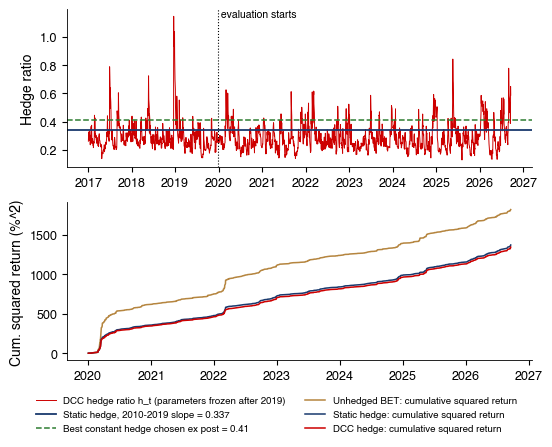

{'ts_a': np.float64(0.05223189895883745),
 'ts_b': np.float64(0.9335175039628505),
 'ts_se_a_hess': np.float64(0.005944150411891652),
 'ts_se_b_hess': np.float64(0.008353161045009647),
 'ts_se_a_one': np.float64(0.0051296690661594),
 'ts_se_b_one': np.float64(0.007650551280667527),
 'ts_se_a_two': np.float64(0.005236121941305224),
 'ts_se_b_two': np.float64(0.007723036592155753),
 'ts_se_ab_one': np.float64(0.0037783781815573653),
 'ts_se_ab_two': np.float64(0.00398821410315378),
 'ts_mean_a_two': np.float64(0.0522824498324997),
 'ts_mean_b_two': np.float64(0.9318060533439744),
 'ts_B': 199,
 'cccb_lr_obs': np.float64(533.4292714788685),
 'cccb_lr_null_q95': np.float64(6.64284850227924),
 'cccb_lr_null_max': np.float64(15.727479415855953),
 'cccb_lr_p_boot': np.float64(0.005),
 'cccb_lr_B': 199,
 'cccb_btc_lr_obs': np.float64(105.61003527258494),
 'cccb_btc_lr_null_q95': np.float64(6.689885924973434),
 'cccb_btc_lr_null_max': np.float64(12.414348831353408),
 'cccb_btc_lr_p_boot': np.fl

In [19]:
def simulate_garch(mu, omega, alpha, beta, eps):
    """Returns (in %) from a GARCH(1,1) with constant mean and the standardised innovations eps."""
    T = len(eps)
    r = np.empty(T)
    s2 = omega / (1 - alpha - beta)
    for t in range(T):
        r[t] = mu + np.sqrt(s2) * eps[t]
        s2 = omega + alpha * (r[t] - mu) ** 2 + beta * s2
    return r


def two_step_bootstrap(B=199):
    """Parametric residual bootstrap for (a, b): (i) step 2 only (DCC re-estimated on the simulated residuals),
    (ii) both steps (simulated GARCH returns, GARCH re-estimated, then DCC). The same innovations in (i) and (ii)."""
    R = joint_returns(['spy', 'tlt'])
    P, V, Z, _ = garch_all(R)
    d = dcc_fit(Z)
    X = Z.values
    L = np.linalg.cholesky(d['R'])
    eta = np.linalg.solve(L, X[:, :, None])[:, :, 0]
    eta = (eta - eta.mean(0)) / eta.std(0)
    rng = np.random.default_rng(SEED)
    one, two = [], []
    for _ in range(B):
        eps = simulate_dcc2(d['a'], d['b'], d['Qbar'], eta[rng.integers(0, len(eta), len(eta))])
        d1 = dcc_fit(pd.DataFrame(eps))
        one.append((d1['a'], d1['b']))
        sim = {c: simulate_garch(P.loc['mu', c], P.loc['omega', c], P.loc['alpha[1]', c], P.loc['beta[1]', c], eps[:, k])
               for k, c in enumerate(R.columns)}
        Rs = pd.DataFrame(sim, index=R.index) / 100
        _, _, Zs, _ = garch_all(Rs)
        d2 = dcc_fit(Zs)
        two.append((d2['a'], d2['b']))
    one, two = np.array(one), np.array(two)
    N.update(ts_a=d['a'], ts_b=d['b'], ts_se_a_hess=d['se_a'], ts_se_b_hess=d['se_b'],
             ts_se_a_one=one[:, 0].std(ddof=1), ts_se_b_one=one[:, 1].std(ddof=1),
             ts_se_a_two=two[:, 0].std(ddof=1), ts_se_b_two=two[:, 1].std(ddof=1),
             ts_se_ab_one=one.sum(1).std(ddof=1), ts_se_ab_two=two.sum(1).std(ddof=1),
             ts_mean_a_two=two[:, 0].mean(), ts_mean_b_two=two[:, 1].mean(), ts_B=B)
    return one, two


def ccc_null_bootstrap(names, tag, B=199):
    """p-value of the DCC-against-CCC statistic under H0: CCC. Constant-correlation innovations from the resampled
    decorrelated residuals, GARCH(1,1) returns simulated with the estimated parameters, then BOTH steps re-estimated on each path
    (univariate GARCH, target Qbar, (a, b)); the observed statistic is computed with the same procedure."""
    R = joint_returns(names)
    P, V, Z, _ = garch_all(R)
    d = dcc_fit(Z)
    lr_obs = 2 * (d['loglik'] - d['ccc_loglik'])
    X = Z.values
    Qbar = np.cov(X.T, bias=True)
    C = Qbar / np.sqrt(np.outer(np.diag(Qbar), np.diag(Qbar)))
    eta = np.linalg.solve(np.linalg.cholesky(C), X.T).T
    eta = (eta - eta.mean(0)) / eta.std(0)
    rng = np.random.default_rng(SEED)
    lrs = []
    for _ in range(B):
        eps = simulate_dcc2(0.0, 0.0, C, eta[rng.integers(0, len(eta), len(eta))])
        sim = {c: simulate_garch(P.loc['mu', c], P.loc['omega', c], P.loc['alpha[1]', c], P.loc['beta[1]', c], eps[:, k])
               for k, c in enumerate(R.columns)}
        _, _, Zs, _ = garch_all(pd.DataFrame(sim, index=R.index) / 100)
        ds = dcc_fit(Zs)
        lrs.append(2 * (ds['loglik'] - ds['ccc_loglik']))
    lrs = np.array(lrs)
    N.update({f'{tag}_lr_obs': lr_obs, f'{tag}_lr_null_q95': np.percentile(lrs, 95), f'{tag}_lr_null_max': lrs.max(),
              f'{tag}_lr_p_boot': (1 + np.sum(lrs >= lr_obs)) / (B + 1), f'{tag}_lr_B': B})


def garch_fixed(r_full, params):
    """Conditional volatility and standardised residuals over the whole period, with the parameters fixed."""
    res = arch_model(100 * r_full, mean='Constant', vol='GARCH', p=1, q=1).fix(params)
    return res.conditional_volatility, res.resid / res.conditional_volatility


def nw_tstat(d):
    """t statistic of the mean with a Newey-West standard error (L = floor(4 (T/100)^(2/9)))."""
    d = np.asarray(d, float)
    T = len(d)
    L = int(np.floor(4 * (T / 100) ** (2 / 9)))
    return d.mean() / np.sqrt(bartlett_lrv(d[:, None], L)[0, 0] / T)


def fig_hedge_oos(h_all, h_static, h_expost, e_un, e_st, e_dc, split):
    """DCC hedge ratio (parameters estimated up to 2019, then fixed) against the static hedge, and
    the cumulative sum of squared hedged returns over the evaluation period."""
    fig, axes = plt.subplots(2, 1, figsize=(5.6, 4.0))
    ax = axes[0]
    h = h_all.loc['2017-01-01':]
    ax.plot(h.index, h, color=IDAred, lw=0.7, label='DCC hedge ratio h_t (parameters frozen after 2019)')
    ax.axhline(h_static, color=MainBlue, lw=1.3, label=f'Static hedge, 2010-2019 slope = {h_static:.3f}')
    ax.axhline(h_expost, color=Forest, lw=1.1, ls='--', label=f'Best constant hedge chosen ex post = {h_expost:.2f}')
    ax.axvline(pd.Timestamp(split), color='black', lw=0.8, ls=':')
    ax.text(pd.Timestamp(split), ax.get_ylim()[1], ' evaluation starts', va='top', fontsize=7.5, color='black')
    ax.set_ylabel('Hedge ratio')
    ax = axes[1]
    for e, col, lab in ((e_un, Amber, 'Unhedged BET'), (e_st, MainBlue, 'Static hedge'), (e_dc, IDAred, 'DCC hedge')):
        ax.plot(e.index, np.cumsum((100 * e) ** 2), color=col, lw=1.1, label=f'{lab}: cumulative squared return')
    ax.set_ylabel('Cum. squared return (%^2)')
    hs, ls_ = [], []
    for a_ in axes:
        h_, l_ = a_.get_legend_handles_labels()
        hs += h_
        ls_ += l_
    fig.tight_layout()
    fig.legend(hs, ls_, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False, fontsize=7)
    save_fig('ch6_hedge_oos')


def hedge_oos(split='2019-12-31'):
    R = joint_returns(['bet', 'stoxx'], start='2010-01-01')
    est, oos = R.loc[R.index <= pd.Timestamp(split)], R.loc[R.index > pd.Timestamp(split)]
    h_static = np.cov(est['bet'], est['stoxx'])[0, 1] / est['stoxx'].var()
    vols, Zs = {}, {}
    for c in R.columns:
        p = arch_model(100 * est[c], mean='Constant', vol='GARCH', p=1, q=1).fit(disp='off').params
        vols[c], Zs[c] = garch_fixed(R[c], p)
    Z = pd.DataFrame(Zs)
    V = pd.DataFrame(vols)
    d = dcc_fit(Z.loc[:split])
    Rt = dcc_path(Z.values, d['a'], d['b'], d['Qbar'])
    h = pd.Series(Rt[:, 0, 1] * V['bet'].values / V['stoxx'].values, index=R.index).loc[oos.index]
    e_un = oos['bet']
    e_st = oos['bet'] - h_static * oos['stoxx']
    e_dc = oos['bet'] - h * oos['stoxx']
    b_oos = np.cov(oos['bet'], oos['stoxx'])[0, 1] / oos['stoxx'].var()
    e_ex = oos['bet'] - b_oos * oos['stoxx']
    vr = lambda e: 1 - e.var() / e_un.var()
    dm = nw_tstat((1e4 * e_st) ** 2 - (1e4 * e_dc) ** 2)
    fig_hedge_oos(pd.Series(Rt[:, 0, 1] * V['bet'].values / V['stoxx'].values, index=R.index), h_static, b_oos,
                  e_un, e_st, e_dc, split)
    N.update(ho_h_static=h_static, ho_h_mean=h.mean(), ho_h_min=h.min(), ho_h_max=h.max(), ho_vr_static=vr(e_st),
             ho_vr_dcc=vr(e_dc), ho_vr_expost=vr(e_ex), ho_h_expost=b_oos, ho_dm=dm, ho_dm_p=1 - stats.norm.cdf(dm),
             ho_n_est=len(est), ho_n_oos=len(oos), ho_a=d['a'], ho_b=d['b'], ho_start=str(R.index[0].date()))


two_step_bootstrap()
ccc_null_bootstrap(['spy', 'tlt'], 'cccb')
ccc_null_bootstrap(['btc', 'spy'], 'cccb_btc')
hedge_oos()
{k: v for k, v in N.items() if k.startswith(('ts_', 'cccb', 'ho_'))}

## 16. Forbes–Rigobon with an estimated variance ratio

- Delta method in $(\hat\rho_c,\hat\delta)$ with their covariance $\approx(1+\delta)\rho_c(1-\rho_c^2)/n_c$ (both use the crisis window); the test of $\rho^*-\hat\rho_{calm}$ also uses $\Cov(\hat\delta,\hat\rho_{calm})$.
- The Fisher test of $\rho^*$ used by Forbes and Rigobon (2002) is conservative: with $\delta$ fixed, $\Var(\operatorname{artanh}\rho^*)\approx1/[n_c(1+\delta(1-\rho_c^2))]$; the inference we rely on is the stationary block bootstrap.

In [20]:
def fr_delta_method(rc, delta, n_c, n_0):
    """Standard error of rho* = rho_c / sqrt(1 + delta (1 - rho_c^2)): with delta fixed and with delta random.
    i.i.d. Normal approximations, independent windows: Var(rho_c) ~ (1 - rho_c^2)^2 / n_c,
    Var(delta) ~ 2 (1 + delta)^2 (1/(n_c-1) + 1/(n_0-1)) and the covariance Cov(rho_c, delta) ~ (1 + delta) rho_c (1 - rho_c^2) / n_c
    (the correlation and the source variance are estimated from the same crisis window)."""
    k = 1 + delta * (1 - rc ** 2)
    g_r, g_d = (1 + delta) / k ** 1.5, -rc * (1 - rc ** 2) / (2 * k ** 1.5)
    v_r, v_d = (1 - rc ** 2) ** 2 / n_c, 2 * (1 + delta) ** 2 * (1 / (n_c - 1) + 1 / (n_0 - 1))
    c_rd = (1 + delta) * rc * (1 - rc ** 2) / n_c
    return (np.sqrt(g_r ** 2 * v_r), np.sqrt(g_r ** 2 * v_r + g_d ** 2 * v_d + 2 * g_r * g_d * c_rd), g_r, g_d,
            np.sqrt(v_d), c_rd)


def fr_bootstrap(calm, crisis, tag, B=1999, block=10):
    r2 = two_day_returns(['sp500', 'stoxx', 'bet'])
    c0, c1 = r2.loc[calm[0]:calm[1]], r2.loc[crisis[0]:crisis[1]]
    rng = np.random.default_rng(SEED)
    delta = c1['sp500'].var() / c0['sp500'].var() - 1
    N[f'frb_{tag}_delta'] = delta
    for tg in ('stoxx', 'bet'):
        r0, rc = c0['sp500'].corr(c0[tg]), c1['sp500'].corr(c1[tg])
        adj = fr_adjust(rc, delta)
        dif = []
        for _ in range(B):
            a = c0.values[stationary_bootstrap_idx(len(c0), block, rng)]
            b = c1.values[stationary_bootstrap_idx(len(c1), block, rng)]
            j = list(r2.columns).index(tg)
            dl = b[:, 0].var(ddof=1) / a[:, 0].var(ddof=1) - 1
            dif.append((fr_adjust(np.corrcoef(b[:, 0], b[:, j])[0, 1], dl) - np.corrcoef(a[:, 0], a[:, j])[0, 1], dl,
                        fr_adjust(np.corrcoef(b[:, 0], b[:, j])[0, 1], dl)))
        dif = np.array(dif)
        se_fix, se_rand, g_r, g_d, se_d, c_rd = fr_delta_method(rc, delta, len(c1) // 2, len(c0) // 2)
        z_fix = (np.arctanh(adj) - np.arctanh(r0)) / np.sqrt(1 / (len(c1) // 2 - 3) + 1 / (len(c0) // 2 - 3))
        # test on the rho scale with the standard error of the difference (random delta), calm window treated as i.i.d. Normal;
        # rho_calm and delta use the same calm window: Cov(rho*, rho_calm) = g_d Cov(delta, rho_calm),
        # Cov(delta, rho_calm) ~ -(1 + delta) rho_calm (1 - rho_calm^2) / n_0
        se0 = (1 - r0 ** 2) / np.sqrt(len(c0) // 2)
        c_s0 = -g_d * (1 + delta) * r0 * (1 - r0 ** 2) / (len(c0) // 2)
        z_rand = (adj - r0) / np.sqrt(se_rand ** 2 + se0 ** 2 - 2 * c_s0)
        z_fixr = (adj - r0) / np.sqrt(se_fix ** 2 + se0 ** 2)
        N.update({f'frb_{tag}_{tg}_adj': adj, f'frb_{tag}_{tg}_r0': r0, f'frb_{tag}_{tg}_rc': rc,
                  f'frb_{tag}_{tg}_p_boot': np.mean(dif[:, 0] <= 0), f'frb_{tag}_{tg}_ci_lo': np.percentile(dif[:, 2], 5),
                  f'frb_{tag}_{tg}_ci_hi': np.percentile(dif[:, 2], 95), f'frb_{tag}_{tg}_se_boot': dif[:, 2].std(ddof=1),
                  f'frb_{tag}_{tg}_se_fix': se_fix, f'frb_{tag}_{tg}_se_rand': se_rand, f'frb_{tag}_{tg}_g_r': g_r,
                  f'frb_{tag}_{tg}_g_d': g_d, f'frb_{tag}_{tg}_z_fixr': z_fixr, f'frb_{tag}_{tg}_z_rand': z_rand,
                  f'frb_{tag}_{tg}_p_fixr': 1 - stats.norm.cdf(z_fixr), f'frb_{tag}_{tg}_p_rand': 1 - stats.norm.cdf(z_rand),
                  f'frb_{tag}_{tg}_z_fisher': z_fix, f'frb_{tag}_{tg}_c_rd': c_rd,
                  f'frb_{tag}_{tg}_z_fisher_k': (np.arctanh(adj) - np.arctanh(r0))
                  / np.sqrt(1 / ((len(c1) // 2) * (1 + delta * (1 - rc ** 2))) + 1 / (len(c0) // 2))})
        N[f'frb_{tag}_se_delta'] = se_d
        N[f'frb_{tag}_delta_boot_lo'], N[f'frb_{tag}_delta_boot_hi'] = np.percentile(dif[:, 1], [5, 95])
    N[f'frb_{tag}_nc'], N[f'frb_{tag}_n0'] = len(c1) // 2, len(c0) // 2
    N['frb_B'], N['frb_block'] = B, block


fr_bootstrap(CALM08, CRISIS08, '08')
{k: v for k, v in N.items() if k.startswith('frb_08')}

{'frb_08_delta': 6.544007405625001,
 'frb_08_stoxx_adj': np.float64(0.4421045745106906),
 'frb_08_stoxx_r0': np.float64(0.6098637253334953),
 'frb_08_stoxx_rc': np.float64(0.8043542734716569),
 'frb_08_stoxx_p_boot': np.float64(0.9824912456228114),
 'frb_08_stoxx_ci_lo': np.float64(0.3829014854976371),
 'frb_08_stoxx_ci_hi': np.float64(0.5163689985640287),
 'frb_08_stoxx_se_boot': np.float64(0.040524077641214476),
 'frb_08_stoxx_se_fix': np.float64(0.05484922703547833),
 'frb_08_stoxx_se_rand': np.float64(0.05076997450402866),
 'frb_08_stoxx_g_r': np.float64(1.2526651965070925),
 'frb_08_stoxx_g_d': np.float64(-0.023574498446230704),
 'frb_08_stoxx_z_fixr': np.float64(-2.1188709236347325),
 'frb_08_stoxx_z_rand': np.float64(-2.4439842877890428),
 'frb_08_stoxx_p_fixr': np.float64(0.9829493115830701),
 'frb_08_stoxx_p_rand': np.float64(0.9927369704259136),
 'frb_08_stoxx_z_fisher': np.float64(-1.4909320524015723),
 'frb_08_stoxx_c_rd': np.float64(0.03295553008265719),
 'frb_08_stoxx_z_f

## 17. Copula inference: Kendall's tau, CML standard errors, Chen–Fan, tail asymmetry and a dynamic t copula

- Tail asymmetry at fixed $q$: i.i.d. bootstrap (static innovation copula) and a stationary block bootstrap with the Politis–White block length.

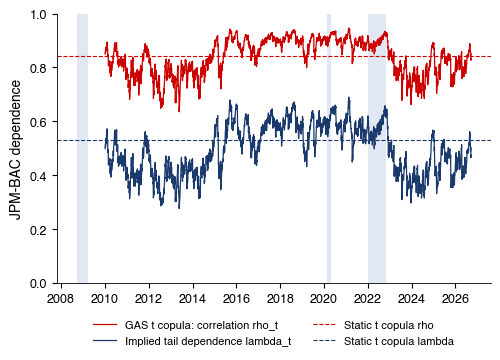

{'ri_tau': np.float64(0.640777489913385),
 'ri_se_tau': np.float64(0.006546564306939901),
 'ri_rho_tau': np.float64(0.8449816893104376),
 'ri_se_rho_tau': np.float64(0.005499470103203594),
 'ri_rho_cml': 0.8417643912247071,
 'ri_nu_cml': 4.241349588643531,
 'ri_se_rho_naive': np.float64(0.004575646450055565),
 'ri_se_rho_ggr': np.float64(0.005333670677733905),
 'ri_se_nu_naive': np.float64(0.35864842258204344),
 'ri_se_nu_ggr': np.float64(0.363942056018062),
 'ri_n': 4202,
 'ts_diff05': np.float64(0.06187529747739173),
 'ts_lo05': np.float64(-0.014278914802475007),
 'ts_hi05': np.float64(0.14754878629224183),
 'ts_diff01': np.float64(0.0951927653498334),
 'ts_lo01': np.float64(-0.0951927653498334),
 'ts_hi01': np.float64(0.28557829604950014),
 'tsb_blk05': 1.6032818683780377,
 'tsb_lo05': np.float64(-0.014278914802475007),
 'tsb_hi05': np.float64(0.13826749167063285),
 'tsb_se05': np.float64(0.040065735045186804),
 'tsb_acmax05': 0.044740883178961716,
 'tsb_blk01': 1.0,
 'tsb_lo01': np

In [21]:
def emp_copula_at_points(u, v, chunk=2000):
    n = len(u)
    out = np.empty(n)
    for i in range(0, n, chunk):
        out[i:i + chunk] = np.mean((u[None, :] <= u[i:i + chunk, None]) & (v[None, :] <= v[i:i + chunk, None]), axis=1)
    return out


def tau_se(u, v):
    """Standard error of Kendall's tau from the Hoeffding projection: 4 sd(2 C_n(U, V) - U - V) / sqrt(n)."""
    W = 2 * emp_copula_at_points(u, v) - u - v
    return kendall_tau(u, v), 4 * W.std() / np.sqrt(len(u))


def cml_se(fam, par, u, v, hp=1e-5, hu=1e-6):
    """CML standard errors: the inverse Hessian (known margins) and the Genest-Ghoudi-Rivest (1995) sandwich,
    in which the score gets the terms W1(U_i) + W2(V_i) due to the ranks."""
    par = np.asarray(par, float)
    k, n = len(par), len(u)

    def score(p, uu, vv):
        g = np.empty((len(uu), k))
        for j in range(k):
            e = np.zeros(k)
            e[j] = hp * max(1, abs(p[j]))
            g[:, j] = (log_density(fam, p + e, uu, vv) - log_density(fam, p - e, uu, vv)) / (2 * e[j])
        return g
    S = score(par, u, v)
    A = np.zeros((k, k))
    for j in range(k):
        e = np.zeros(k)
        e[j] = 1e-4 * max(1, abs(par[j]))
        A[:, j] = -(score(par + e, u, v) - score(par - e, u, v)).mean(0) / (2 * e[j])
    A = (A + A.T) / 2
    du = (score(par, u + hu, v) - score(par, u - hu, v)) / (2 * hu)
    dv = (score(par, u, v + hu) - score(par, u, v - hu)) / (2 * hu)

    def suffix(x, D):
        o = np.argsort(x)
        cs = np.cumsum(D[o][::-1], axis=0)[::-1] / n
        out = np.empty_like(D)
        out[o] = cs
        return out
    Ai = np.linalg.inv(A)
    Bg = np.atleast_2d(np.cov((S + suffix(u, du) + suffix(v, dv)).T))
    return np.sqrt(np.diag(Ai) / n), np.sqrt(np.diag(Ai @ Bg @ Ai) / n)


def rank_inference():
    Rb, Zb, U = bank_copula_data()
    u, v = U[:, 0], U[:, 1]
    tau, se_tau = tau_se(u, v)
    rho_tau = np.sin(np.pi * tau / 2)
    se_rho_tau = np.pi / 2 * np.cos(np.pi * tau / 2) * se_tau
    ft = fit_copula('t', u, v)
    naive, ggr = cml_se('t', ft['par'], u, v)
    N.update(ri_tau=tau, ri_se_tau=se_tau, ri_rho_tau=rho_tau, ri_se_rho_tau=se_rho_tau, ri_rho_cml=ft['par'][0],
             ri_nu_cml=ft['par'][1], ri_se_rho_naive=naive[0], ri_se_rho_ggr=ggr[0], ri_se_nu_naive=naive[1],
             ri_se_nu_ggr=ggr[1], ri_n=len(u))
    # tail asymmetry: lambda_L(q) - lambda_U(q), i.i.d. bootstrap of residual pairs (re-ranked)
    rng = np.random.default_rng(SEED)
    X = Zb.values
    for q, tag in ((0.05, '05'), (0.01, '01')):
        L0, U0 = empirical_tail_dep(u, v, q)
        db = []
        for _ in range(999):
            Ub = pseudo_obs(X[rng.integers(0, len(X), len(X))])
            lb, ub = empirical_tail_dep(Ub[:, 0], Ub[:, 1], q)
            db.append(lb - ub)
        db = np.array(db)
        N.update({f'ts_diff{tag}': L0 - U0, f'ts_se{tag}': db.std(ddof=1), f'ts_lo{tag}': np.percentile(db, 2.5),
                  f'ts_hi{tag}': np.percentile(db, 97.5), f'ts_k{tag}': int(round(q * len(u)))})
    # S&P 500 / Euro Stoxx 50 weekly (seminar, A2 and B2)
    W = weekly_returns(['sp500', 'stoxx'], start='2000-01-01')
    U2 = pseudo_obs(W.values)
    u2, v2 = U2[:, 0], U2[:, 1]
    t2, se2 = tau_se(u2, v2)
    rs_impl = lambda t: 6 / np.pi * np.arcsin(np.sin(np.pi * t / 2) / 2)
    diff = rs_impl(t2) - spearman_rho(u2, v2)
    bs = []
    for _ in range(1999):
        i = rng.integers(0, len(W), len(W))
        Ub = pseudo_obs(W.values[i])
        tb = kendall_tau(Ub[:, 0], Ub[:, 1])
        bs.append(rs_impl(tb) - spearman_rho(Ub[:, 0], Ub[:, 1]))
    bs = np.array(bs)
    fg, ft2 = fit_copula('gaussian', u2, v2), fit_copula('t', u2, v2)
    ng, gg = cml_se('gaussian', fg['par'], u2, v2)
    nt, gt = cml_se('t', ft2['par'], u2, v2)
    N.update(a2_se_tau=se2, a2_se_clayton=2 / (1 - t2) ** 2 * se2, a2_se_gauss=np.pi / 2 * np.cos(np.pi * t2 / 2) * se2,
             a2_W_sd=se2 * np.sqrt(len(W)) / 4, a2_diff=diff, a2_diff_se=bs.std(ddof=1), a2_diff_lo=np.percentile(bs, 2.5),
             a2_diff_hi=np.percentile(bs, 97.5), b2_se_rho_g_naive=ng[0], b2_se_rho_g_ggr=gg[0], b2_se_rho_t_naive=nt[0],
             b2_se_rho_t_ggr=gt[0], b2_se_nu_naive=nt[1], b2_se_nu_ggr=gt[1])


def chen_fan_mc(R_=500, T=2000, rho=0.8, df=5):
    Rb, Zb, U = bank_copula_data()
    P, _, _, _ = garch_all(Rb)
    rng = np.random.default_rng(SEED)
    est_true, est_res, se_naive, se_ggr = [], [], [], []
    for _ in range(R_):
        Uc = simulate('gaussian', [rho], T, rng)
        eps = stats.t.ppf(Uc, df) / np.sqrt(df / (df - 2))
        Ut = pseudo_obs(eps)
        est_true.append(fit_copula('gaussian', Ut[:, 0], Ut[:, 1])['par'][0])
        sim = {c: simulate_garch(P.loc['mu', c], P.loc['omega', c], P.loc['alpha[1]', c], P.loc['beta[1]', c], eps[:, k])
               for k, c in enumerate(Rb.columns)}
        _, _, Zs, _ = garch_all(pd.DataFrame(sim) / 100)
        Ur = pseudo_obs(Zs.values)
        f = fit_copula('gaussian', Ur[:, 0], Ur[:, 1])
        est_res.append(f['par'][0])
        a, b = cml_se('gaussian', f['par'], Ur[:, 0], Ur[:, 1])
        se_naive.append(a[0])
        se_ggr.append(b[0])
    N.update(cf_sd_true=np.std(est_true, ddof=1), cf_sd_res=np.std(est_res, ddof=1), cf_se_naive=np.mean(se_naive),
             cf_se_ggr=np.mean(se_ggr), cf_theory_ggr=(1 - rho ** 2) / np.sqrt(T),
             cf_theory_naive=(1 - rho ** 2) / np.sqrt((1 + rho ** 2) * T), cf_R=R_, cf_T=T, cf_rho=rho, cf_df=df,
             cf_bias_res=np.mean(est_res) - rho)


def t_score_rho(rho, nu, x, y):
    """d log c_t / d rho for the t copula (x, y = the t_nu quantiles of the pseudo-observations)."""
    Q = x * x + y * y - 2 * rho * x * y
    D = nu * (1 - rho ** 2)
    dQD = (-2 * x * y * (1 - rho ** 2) + 2 * rho * Q) / (nu * (1 - rho ** 2) ** 2)
    return rho / (1 - rho ** 2) - (nu + 2) / 2 * dQD / (1 + Q / D)


@njit(cache=True)
def gas_t_nll(om, A, Bp, nu, x, y, cst):
    """Minus the log-likelihood of the GAS t copula (same recursion as gas_filter); x, y = the t_nu quantiles."""
    f = om / (1.0 - Bp)
    ll = 0.0
    for t in range(len(x)):
        r = np.tanh(f)
        if abs(r) >= 0.9999:
            return 1e10
        Q = x[t] * x[t] + y[t] * y[t] - 2.0 * r * x[t] * y[t]
        D = nu * (1.0 - r * r)
        ll += (cst - 0.5 * np.log(1.0 - r * r) - (nu + 2.0) / 2.0 * np.log1p(Q / D)
               + (nu + 1.0) / 2.0 * (np.log1p(x[t] * x[t] / nu) + np.log1p(y[t] * y[t] / nu)))
        dQD = (-2.0 * x[t] * y[t] * (1.0 - r * r) + 2.0 * r * Q) / (nu * (1.0 - r * r) ** 2)
        s = (r / (1.0 - r * r) - (nu + 2.0) / 2.0 * dQD / (1.0 + Q / D)) * (1.0 - r * r)
        f = om + A * s + Bp * f
    return -ll


def gas_filter(theta, u, v):
    om, A, Bp, nu = theta
    x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
    T = len(u)
    f = np.empty(T)
    f[0] = om / (1 - Bp)
    for t in range(T - 1):
        r = np.tanh(f[t])
        s = t_score_rho(r, nu, x[t], y[t]) * (1 - r * r)
        f[t + 1] = om + A * s + Bp * f[t]
    return np.tanh(f)


def gas_t_copula(u, v):
    fs = fit_copula('t', u, v)
    r0, nu0 = fs['par']

    uc, vc = np.clip(u, 1e-10, 1 - 1e-10), np.clip(v, 1e-10, 1 - 1e-10)

    def nll(p):
        om, A, Bp, lnu = p
        nu = 2.01 + np.exp(lnu)
        if not (0 <= Bp < 0.9995) or A < 0 or A > 1:
            return 1e10
        cst = gammaln((nu + 2) / 2) + gammaln(nu / 2) - 2 * gammaln((nu + 1) / 2)
        return gas_t_nll(om, A, Bp, nu, stats.t.ppf(uc, nu), stats.t.ppf(vc, nu), cst)
    best = None
    for Bp, A in ((0.98, 0.03), (0.95, 0.05), (0.99, 0.01)):
        p0 = [(1 - Bp) * np.arctanh(r0), A, Bp, np.log(nu0 - 2.01)]
        r = optimize.minimize(nll, p0, method='Nelder-Mead', options=dict(xatol=1e-6, fatol=1e-6, maxiter=4000))
        if best is None or r.fun < best.fun:
            best = r
    om, A, Bp, lnu = best.x
    nu = 2.01 + np.exp(lnu)
    rho = gas_filter((om, A, Bp, nu), u, v)
    return dict(om=om, A=A, B=Bp, nu=nu, rho=rho, ll=-best.fun, ll_static=fs['loglik'], rho_static=r0, nu_static=nu0,
                lr=2 * (-best.fun - fs['loglik']))


def fig_gas_copula():
    Rb, Zb, U = bank_copula_data()
    g = gas_t_copula(U[:, 0], U[:, 1])
    rho = pd.Series(g['rho'], index=Zb.index)
    lam = pd.Series(2 * stats.t.cdf(-np.sqrt((g['nu'] + 1) * (1 - rho) / (1 + rho)), g['nu'] + 1), index=rho.index)
    lam_s = 2 * stats.t.cdf(-np.sqrt((g['nu_static'] + 1) * (1 - g['rho_static']) / (1 + g['rho_static'])),
                            g['nu_static'] + 1)
    fig, ax = plt.subplots(figsize=(5.6, 3.5))
    shade_crises(ax)
    ax.plot(rho.index, rho, color=IDAred, lw=0.9, label='GAS t copula: correlation rho_t')
    ax.plot(lam.index, lam, color=MainBlue, lw=0.9, label='Implied tail dependence lambda_t')
    ax.axhline(g['rho_static'], color=IDAred, ls='--', lw=0.8, label='Static t copula rho')
    ax.axhline(lam_s, color=MainBlue, ls='--', lw=0.8, label='Static t copula lambda')
    ax.set_ylabel('JPM-BAC dependence')
    ax.set_ylim(0, 1)
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    save_fig('ch6_gas_copula')
    N.update(gas_om=g['om'], gas_A=g['A'], gas_B=g['B'], gas_nu=g['nu'], gas_ll=g['ll'], gas_ll_static=g['ll_static'],
             gas_lr=g['lr'], gas_rho_min=rho.min(), gas_rho_min_date=str(rho.idxmin().date()), gas_rho_max=rho.max(),
             gas_rho_max_date=str(rho.idxmax().date()), gas_rho_last=rho.iloc[-1], gas_rho_static=g['rho_static'],
             gas_nu_static=g['nu_static'], gas_lam_min=lam.min(), gas_lam_max=lam.max(), gas_lam_static=lam_s,
             gas_rho_2020=rho.loc['2020-03-01':'2020-06-30'].mean(), gas_rho_2019=rho.loc['2019'].mean())
    # seminar, B6: S&P 500 / Euro Stoxx 50 weekly
    W = weekly_returns(['sp500', 'stoxx'], start='2000-01-01')
    U2 = pseudo_obs(W.values)
    g2 = gas_t_copula(U2[:, 0], U2[:, 1])
    r2 = pd.Series(g2['rho'], index=W.index)
    N.update(b6_A=g2['A'], b6_B=g2['B'], b6_nu=g2['nu'], b6_lr=g2['lr'], b6_rho_min=r2.min(),
             b6_rho_min_date=str(r2.idxmin().date()), b6_rho_max=r2.max(), b6_rho_max_date=str(r2.idxmax().date()),
             b6_rho_static=g2['rho_static'], b6_nu_static=g2['nu_static'], b6_om=g2['om'])
    return g


def tail_symmetry_block(q_list=((0.05, '05'), (0.01, '01')), B=999):
    """lambda_L(q) - lambda_U(q) at a fixed threshold q, with a stationary block bootstrap (Politis & Romano, 1994); mean
    block length: the automatic rule of Politis & White (2004), applied to the indicator 1{lower corner} - 1{upper corner}."""
    from arch.bootstrap import optimal_block_length
    Rb, Zb, U = bank_copula_data()
    u, v = U[:, 0], U[:, 1]
    X = Zb.values
    rng = np.random.default_rng(SEED)
    for q, tag in q_list:
        ind = ((u <= q) & (v <= q)).astype(float) - ((u > 1 - q) & (v > 1 - q)).astype(float)
        blk = max(1.0, float(optimal_block_length(ind)['stationary'].iloc[0]))
        L0, U0 = empirical_tail_dep(u, v, q)
        db = []
        for _ in range(B):
            Ub = pseudo_obs(X[stationary_bootstrap_idx(len(X), blk, rng)])
            lb, ub = empirical_tail_dep(Ub[:, 0], Ub[:, 1], q)
            db.append(lb - ub)
        db = np.array(db)
        ac = [np.corrcoef(ind[:-l], ind[l:])[0, 1] for l in range(1, 11)]
        N.update({f'tsb_blk{tag}': blk, f'tsb_lo{tag}': np.percentile(db, 2.5), f'tsb_hi{tag}': np.percentile(db, 97.5),
                  f'tsb_se{tag}': db.std(ddof=1), f'tsb_acmax{tag}': float(np.max(np.abs(ac)))})
    N['tsb_B'] = B


rank_inference()
tail_symmetry_block()
fig_gas_copula()
chen_fan_mc()
{k: v for k, v in N.items() if k.startswith(('ri_', 'ts_d', 'ts_l', 'ts_h', 'tsb', 'gas', 'cf_'))}